<a href="https://colab.research.google.com/github/SeoYun-Y/thinfiler-credit-scoring/blob/feature%2Ftrack-b-11-postvalidation/notebooks/track-b/track_b_11_%E1%84%8A%E1%85%B5%E1%86%AB%E1%84%91%E1%85%A1%E1%84%8B%E1%85%B5%E1%86%AF%E1%84%85%E1%85%A5_%E1%84%89%E1%85%A1%E1%84%92%E1%85%AE%E1%84%80%E1%85%A5%E1%86%B7%E1%84%8C%E1%85%B3%E1%86%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Track B — 씬파일러 스코어링 사후 검증 (track_b_11)

담당: 서윤 | 선행 노트북: track_b_01~06(서윤), track_b_07~10(김태헌)

## 이 노트북을 만든 이유

track_b_03에서 46개, track_b_04에서 69개로 변수를 확정하고 씬파일러 44,110명에게 점수를 매겼다. 그런데 그 점수가 타당한지를 확인하는 작업에는 세 가지 공백이 있었다.

1. **씬파일러 유효성 점검이 갱신되지 않았다.** track_b_02 18번 섹션에서 43개 변수를 대상으로 점검했으나, 이후 편입된 변수들은 점검을 거치지 않았다.
2. **SHAP이 신용이력 보유군에서만 계산됐다.** 정작 적용 대상인 씬파일러에서 어떤 변수가 작동하는지는 확인된 바 없었다.
3. **씬파일러에 정답이 없다고 판단했다.** track_b_01에서 5가지 방법을 시도한 뒤 "씬파일러 세그먼트 내부에서는 유의미한 연체 타겟을 만들 수 없다"고 결론지었고, 이후 검증은 참고신호 240명에 의존했다.

이 노트북은 세 공백을 순서대로 메운다. 특히 3번은 **결론 자체가 뒤집혔다** — 씬파일러 중 이후 신용을 획득한 3,087명(이탈 코호트)에게는 실제 연체 라벨이 존재하며, 이를 이용해 정식 AUC 검증이 가능하다.

## 결과 요약

| 검증 | 결과 |
| --- | --- |
| 69개 변수 씬파일러 유효성 | 해석 주의 변수 **10개 → 23개**로 갱신 (문서 정정 필요) |
| 46개 vs 69개 확장 효과 | 씬파일러 구분력 +0.0121, 대응 부트스트랩 95% CI [+0.0049, +0.0189] → **유의** |
| 씬파일러 SHAP | 변별력 1위 **PYE_AL012G019(휴대폰 이력)**, 결측 구조로 점수가 매겨진다는 우려는 기각 |
| 참고신호 240명 순열검정 | 셔플 1,000회 중 0회 재현, **15.5σ** |
| **이탈 코호트 정식 검증** | 정답 라벨로 AUC 산출 가능 — track_b_01의 "타겟 없음" 결론이 부분 수정됨 |
| 정의 시점 불일치 발견 | 씬파일러 1.38%가 이미 신용활동 시작 상태 — 이들을 제외한 것이 최종 수치 |
| **최종 헤드라인** | **대안변수 AUC 0.7164 vs 기존 신용정보 0.5570** (순열검정 0/1000 vs 113/1000) |

**주의**: 8~10번 섹션의 이탈 코호트 수치(AUC 0.7775 등)는 오염 제거 이전 값이다. **11번 섹션에서 정정되며, 최종 인용 수치는 11번 기준이다.** 중간 수치를 남겨둔 것은 왜 정정이 필요했는지 과정을 보이기 위함이다.

## 용어

- **씬파일러(thin filer)**: 신용거래 이력이 없는 사람. 본 프로젝트에서는 카드 4필드 + 대출 1필드가 모두 0인 경우로 정의한다.
- **이탈 코호트**: 202103 시점 씬파일러였다가 202203 시점에 신용을 획득해 씬파일러를 벗어난 집단.
- **SHAP**: 개별 예측값에 각 변수가 얼마나 기여했는지 분해하는 기법. 크기는 `mean(|SHAP|)`, 변별력은 `std(SHAP)`으로 본다.
- **부트스트랩**: 데이터를 복원추출로 여러 번 다시 뽑아 통계량의 변동폭(신뢰구간)을 추정하는 방법.
- **순열검정(permutation test)**: 정답 라벨을 무작위로 뒤섞은 뒤 같은 계산을 반복해, "우연히 나올 수 있는 값의 범위"를 데이터 자체에서 만들어 비교하는 방법.

---
## 0. 환경설정 및 데이터 준비

이 노트북은 46개(track_b_03), 69개(track_b_04), 66개(인구변수 제외) 세 가지 변수셋을 모두 다루므로, **세 세트의 합집합을 한 번에 로드**한다. 46개에만 있는 `R12M_MED_AMT`와 69개에만 있는 24개가 모두 포함된다.

**시점 구조** (track_b_01에서 확정한 설계를 그대로 따른다)

- **X (예측 재료)**: 202103 파일 = 2020년말 기준 스냅샷
- **씬파일러 판정**: 202103의 5개 정의 필드
- **y (정답)**: 202203의 `PYE_D1011000C` = 2021년 중 발생한 연체

X가 2020년말, y가 2021년 중이므로 시점 누출이 없다.

**전처리 순서**는 track_b_04/05와 동일하다. 결측 플래그를 먼저 생성한 뒤 원본을 0으로 채우고, WOE 인코딩은 정답이 있는 신용이력 보유군에서만 계산해 씬파일러에 그대로 적용한다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import gc

base_path = '/content/drive/MyDrive/멀티캠퍼스 데이터분석_신용평가 데이터'
scan_path = f'{base_path}/통신카드CB_씬파일러.csv'

# ===== track_b_03 최종 46개 =====
features_46 = [
    'DAR', 'PYE_AL012G019', 'TOT_ASST', 'PYE_AL012G005', 'YOY_TOT_ASST_RTC',
    'R3M_ITRT_ENT_BROADCAST', 'AGE', 'OWN_HOUS_CNT', 'FAM_OWN_HOUS_CNT',
    'PYE_CAR_OWN', 'JB_TP', 'FST_CAR_ELPS', 'OWN_LIV_YN', 'FST_HOUS_BUY_ELPS',
    'FAM_OWN_LIV_YN', 'RET_SIL', 'CPYT_CONV_AMT_RT_was_missing',
    'YOY_R3M_FOOD_AMT_RTC', 'R6M_MART_AMT', 'YOY_R3M_SSM_AMT_RTC',
    'HIGHEND_CD2', 'QOQ_TOT_ASST_RTC', 'PYE_AL012G011', 'SHP_CNT',
    'R3M_ITRT_SHOP_JIKGU', 'YOY_R3M_MART_AMT_RTC', 'B1Y_MOB_OS',
    'CPYT_FOOD_AMT_RT_was_missing', 'QOQ_R3M_MART_AMT_RTC', 'HOME_ADM',
    'YOY_R3M_HOUSEHOLD_AMT_RTC', 'R3M_ITRT_ENT_WEBTOON', 'R12M_MED_AMT',
    'R3M_ITRT_FIN_INSUR', 'YOY_R3M_ITRT_COMM_VOIP_CS', 'YOY_R3M_CONV_AMT_RTC',
    'R6M_M_MART_AMT', 'YOY_R3M_M_CONV_AMT_RTC',
    'grade_unavailable', 'PET_GD_woe', 'APP_GD_woe', 'GOLF_GD_woe', 'TRAVEL_GD_woe',
    'DAR_was_missing', 'FST_CAR_ELPS_was_missing', 'FST_HOUS_BUY_ELPS_was_missing',
]
features_46 = list(dict.fromkeys(features_46))

# ===== track_b_04 최종 69개 =====
features_69 = [
    'DAR', 'PYE_AL012G019', 'TOT_ASST', 'PYE_AL012G005', 'YOY_TOT_ASST_RTC',
    'R3M_ITRT_ENT_BROADCAST', 'AGE', 'OWN_HOUS_CNT', 'FAM_OWN_HOUS_CNT',
    'PYE_CAR_OWN', 'JB_TP', 'FST_CAR_ELPS', 'OWN_LIV_YN', 'FST_HOUS_BUY_ELPS',
    'FAM_OWN_LIV_YN', 'RET_SIL', 'HIGHEND_CD2', 'QOQ_TOT_ASST_RTC',
    'PYE_AL012G011', 'SHP_CNT', 'R3M_ITRT_SHOP_JIKGU', 'B1Y_MOB_OS',
    'HOME_ADM', 'R3M_ITRT_ENT_WEBTOON', 'R3M_ITRT_FIN_INSUR',
    'YOY_R3M_ITRT_COMM_VOIP_CS',
    'YOY_R3M_FOOD_AMT_RTC', 'R6M_MART_AMT', 'YOY_R3M_SSM_AMT_RTC',
    'YOY_R3M_MART_AMT_RTC', 'QOQ_R3M_MART_AMT_RTC',
    'YOY_R3M_HOUSEHOLD_AMT_RTC', 'YOY_R3M_CONV_AMT_RTC',
    'R6M_M_MART_AMT', 'YOY_R3M_M_CONV_AMT_RTC',
    'R6M_SSM_AMT', 'R6M_MED_AMT', 'R6M_HOUSEHOLD_AMT', 'R6M_OIL_AMT',
    'R6M_FOOD_AMT', 'R6M_CONV_AMT', 'R6M_BEAUTY_AMT', 'R6M_CUL_AMT',
    'R6M_M_CONV_AMT', 'QOQ_R3M_HOUSEHOLD_AMT_RTC', 'QOQ_R3M_E_COMM_AMT_RTC',
    'YOY_R3M_E_COMM_AMT_RTC_was_missing', 'YOY_R3M_STARBUCKS_AMT_RTC_was_missing',
    'CPYT_MART_AMT_RT', 'CPYT_CLOTHES_AMT_RT_was_missing', 'CPYT_HOUSEHOLD_AMT_RT',
    'CPYT_SSM_AMT_RT_was_missing', 'CPYT_M_CONV_AMT_RT', 'CPYT_OIL_AMT_RT_was_missing',
    'CPYT_SSM_AMT_RT', 'CPYT_E_COMM_AMT_RT', 'CPYT_STARBUCKS_AMT_RT_was_missing',
    'CPYT_MART_AMT_RT_was_missing', 'CPYT_STARBUCKS_AMT_RT',
    'grade_unavailable', 'PET_GD_woe', 'APP_GD_woe', 'GOLF_GD_woe', 'TRAVEL_GD_woe',
    'DAR_was_missing', 'FST_CAR_ELPS_was_missing', 'FST_HOUS_BUY_ELPS_was_missing',
    'CPYT_CONV_AMT_RT_was_missing', 'CPYT_FOOD_AMT_RT_was_missing'
]
features_69 = list(dict.fromkeys(features_69))
final_69_features = features_69  # 이후 셀 호환용 별칭

print(f"46개 세트: {len(features_46)}개 / 69개 세트: {len(features_69)}개")
print(f"46개에만 있는 변수: {[c for c in features_46 if c not in features_69]}")
print(f"69개에만 있는 변수: {len([c for c in features_69 if c not in features_46])}개")

# ===== 합집합 기준 로드 =====
all_features = list(dict.fromkeys(features_46 + features_69))
grade_source_cols = ['PET_GD', 'APP_GD', 'GOLF_GD', 'TRAVEL_GD']
derived_cols = ['grade_unavailable', 'PET_GD_woe', 'APP_GD_woe', 'GOLF_GD_woe', 'TRAVEL_GD_woe']
thin_def_cols = ['PYE_C1M210000', 'PYE_C18233003', 'PYE_C18233004', 'PYE_C18233005', 'PYE_L10210000']

flag_derived = [c for c in all_features if c.endswith('_was_missing')]
raw_source_of_flags = [c.replace('_was_missing', '') for c in flag_derived]
direct_load = [c for c in all_features if not c.endswith('_was_missing') and c not in derived_cols]

load_cols = list(dict.fromkeys(['CUST_ID'] + direct_load + raw_source_of_flags + grade_source_cols + thin_def_cols))
df = pd.read_csv(f'{scan_path}/202103_통신카드CB결합.csv', usecols=load_cols)
gc.collect()

# 결측 플래그 생성 -> 원본 0으로 채움 (순서 중요)
flag_source_df = df[raw_source_of_flags].isnull().astype(int)
flag_source_df.columns = [f'{c}_was_missing' for c in raw_source_of_flags]
df = pd.concat([df, flag_source_df], axis=1)
df[raw_source_of_flags] = df[raw_source_of_flags].fillna(0)
del flag_source_df
df[direct_load] = df[direct_load].fillna(0)
gc.collect()

# 씬파일러 정의 (202103 기준, 5필드 전부 0)
thin_mask = (
    (df['PYE_C1M210000']==0) & (df['PYE_C18233003']==0) &
    (df['PYE_C18233004']==0) & (df['PYE_C18233005']==0) &
    (df['PYE_L10210000']==0)
)
df['segment'] = np.where(thin_mask, 'thin_filer', 'credit_holder')

# 타겟 (202203의 1년내 연체발생)
df_y = pd.read_csv(f'{scan_path}/202203_통신카드CB결합.csv', usecols=['CUST_ID', 'PYE_D1011000C'])
df_y['TARGET'] = (df_y['PYE_D1011000C'] > 0).astype(int)
df = df.merge(df_y[['CUST_ID', 'TARGET']], on='CUST_ID', how='left')
del df_y
gc.collect()

credit_holders = df[df['segment']=='credit_holder'].copy()
thin_filers = df[df['segment']=='thin_filer'].copy()
del df
gc.collect()

# WOE 인코딩 (신용이력 보유군에서 계산 -> 씬파일러에 매핑만 적용)
credit_holders['grade_unavailable'] = (credit_holders['PET_GD'] == '*').astype(int)
thin_filers['grade_unavailable'] = (thin_filers['PET_GD'] == '*').astype(int)

def woe_encode_nonstar(df_, feature, target):
    data = df_[df_[feature] != '*'][[feature, target]].copy()
    grouped = data.groupby(feature, observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    total_bad, total_good = grouped['bad'].sum(), grouped['good'].sum()
    grouped['bad_rate'] = (grouped['bad'] + 0.5) / (total_bad + 0.5)
    grouped['good_rate'] = (grouped['good'] + 0.5) / (total_good + 0.5)
    grouped['woe'] = np.log(grouped['good_rate'] / grouped['bad_rate'])
    return grouped['woe'].to_dict()

for col in grade_source_cols:
    woe_map = woe_encode_nonstar(credit_holders, col, 'TARGET')
    credit_holders[f'{col}_woe'] = credit_holders[col].map(woe_map).fillna(0)
    thin_filers[f'{col}_woe'] = thin_filers[col].map(woe_map).fillna(0)
gc.collect()

print(f"\n신용이력 보유군: {len(credit_holders):,}명 / 씬파일러: {len(thin_filers):,}명")
print(f"결측 확인 - CH: {credit_holders[all_features].isnull().sum().sum()}, TF: {thin_filers[all_features].isnull().sum().sum()}")

Mounted at /content/drive
46개 세트: 46개 / 69개 세트: 69개
46개에만 있는 변수: ['R12M_MED_AMT']
69개에만 있는 변수: 24개

신용이력 보유군: 285,890명 / 씬파일러: 44,110명
결측 확인 - CH: 0, TF: 0


**실행 결과**: 신용이력 보유군 285,890명 / 씬파일러 44,110명, 결측 0. track_b_01~04와 일치한다.

---
## 1. 69개 변수의 씬파일러 유효성 점검

### 왜 다시 점검하는가

track_b_02 18번 섹션에서 "씬파일러 세그먼트 유효성 사전 점검"을 수행해 해석 주의 변수 10개를 식별했고, 이 목록이 track_b_03 전달사항에 그대로 실렸다. 그런데 이 결과에는 두 가지 시차 문제가 있다.

1. **결측 처리 시점**: 18번 섹션은 19번 섹션의 `fillna(0)` 처리 **이전**에 실행됐다. `value_counts(normalize=True)`는 결측을 제외하고 계산하므로, 결측률 68%인 `FST_CAR_ELPS`는 비결측 32% 안에서만 최빈값 비율이 계산됐다(1.5%). 결측을 0으로 채운 뒤에는 그 68%가 모두 0이 되면서 95.6%로 바뀐다.
2. **변수 추가**: track_b_03에서 결측 플래그 3개, track_b_04에서 24개가 추가됐으나 점검을 거치지 않았다.

**점검 기준**은 18번 섹션과 동일하다 — 씬파일러 내 최빈값 비율이 90% 이상이면 "해석 주의". 그 값이 사실상 상수라 변별에 기여하기 어렵다는 뜻이다.

In [2]:
# track_b_03 시점의 46개 목록 (비교 기준)
# 주의: 이 중 결측 플래그 3개(DAR/FST_CAR_ELPS/FST_HOUS_BUY_ELPS_was_missing)는
#       track_b_02 19번 섹션에서 생성됐으므로 18번 섹션 점검 대상이 아니었다.
features_46_baseline = features_46

newly_added = [c for c in final_69_features if c not in features_46_baseline]
print(f"기존 46개 세트에 포함돼 있던 변수: {len([c for c in final_69_features if c in features_46_baseline])}개")
print(f"track_b_04에서 신규 편입: {len(newly_added)}개")
print(newly_added)

# 69개 전체 점검
check_results = []
for col in final_69_features:
    ch_vc = credit_holders[col].value_counts(normalize=True)
    tf_vc = thin_filers[col].value_counts(normalize=True)

    ch_top_ratio = ch_vc.iloc[0] * 100
    tf_top_ratio = tf_vc.iloc[0] * 100
    tf_top_value = tf_vc.index[0]

    check_results.append({
        '변수명': col,
        '신규점검': 'Y' if col in newly_added else '',
        '신용이력군_최빈값비율(%)': round(ch_top_ratio, 1),
        '씬파일러_최빈값비율(%)': round(tf_top_ratio, 1),
        '차이(%p)': round(tf_top_ratio - ch_top_ratio, 1),
        '씬파일러_최빈값': tf_top_value,
        '씬파일러_고유값수': thin_filers[col].nunique(),
    })

check_df = pd.DataFrame(check_results).sort_values('씬파일러_최빈값비율(%)', ascending=False)
pd.set_option('display.max_rows', None)
print("\n=== 69개 전체 씬파일러 유효성 점검 (최빈값 비율 내림차순) ===")
print(check_df.to_string(index=False))

기존 46개 세트에 포함돼 있던 변수: 45개
track_b_04에서 신규 편입: 24개
['R6M_SSM_AMT', 'R6M_MED_AMT', 'R6M_HOUSEHOLD_AMT', 'R6M_OIL_AMT', 'R6M_FOOD_AMT', 'R6M_CONV_AMT', 'R6M_BEAUTY_AMT', 'R6M_CUL_AMT', 'R6M_M_CONV_AMT', 'QOQ_R3M_HOUSEHOLD_AMT_RTC', 'QOQ_R3M_E_COMM_AMT_RTC', 'YOY_R3M_E_COMM_AMT_RTC_was_missing', 'YOY_R3M_STARBUCKS_AMT_RTC_was_missing', 'CPYT_MART_AMT_RT', 'CPYT_CLOTHES_AMT_RT_was_missing', 'CPYT_HOUSEHOLD_AMT_RT', 'CPYT_SSM_AMT_RT_was_missing', 'CPYT_M_CONV_AMT_RT', 'CPYT_OIL_AMT_RT_was_missing', 'CPYT_SSM_AMT_RT', 'CPYT_E_COMM_AMT_RT', 'CPYT_STARBUCKS_AMT_RT_was_missing', 'CPYT_MART_AMT_RT_was_missing', 'CPYT_STARBUCKS_AMT_RT']

=== 69개 전체 씬파일러 유효성 점검 (최빈값 비율 내림차순) ===
                                  변수명 신규점검  신용이력군_최빈값비율(%)  씬파일러_최빈값비율(%)  차이(%p)   씬파일러_최빈값  씬파일러_고유값수
                          HIGHEND_CD2                 95.2           99.9     4.7   0.000000          2
                              RET_SIL                 94.3           99.2     4.9   0.000000          2
             

### 1-2. 판정 및 계열별 집중 확인

90% 이상 쏠린 변수를 추려내고, 특히 track_b_04에서 새로 들어온 CPYT 결측플래그와 R6M 소비금액 계열이 씬파일러에서 어떤 상태인지 확인한다. 이 두 계열은 카드 사용을 전제하므로 씬파일러에서 무력화될 가능성이 가장 높다.

In [3]:
# 1. 90% 이상 쏠림 변수 (해석 주의 대상)
severe_skew = check_df[check_df['씬파일러_최빈값비율(%)'] >= 90]
print(f"=== 씬파일러 내 90% 이상 쏠림: {len(severe_skew)}개 ===")
print(severe_skew[['변수명','신규점검','신용이력군_최빈값비율(%)','씬파일러_최빈값비율(%)','씬파일러_최빈값']].to_string(index=False))

# 2. 그중 이번에 처음 점검된 것
new_severe = severe_skew[severe_skew['신규점검']=='Y']
print(f"\n=== 그중 신규 편입 변수: {len(new_severe)}개 ===")
if len(new_severe) > 0:
    print(new_severe[['변수명','씬파일러_최빈값비율(%)','씬파일러_최빈값']].to_string(index=False))
else:
    print("없음 — 신규 편입 변수 모두 씬파일러에서 유효한 분산 확보")

# 3. CPYT 결측플래그 계열 — 씬파일러에서 '활동없음(1)' 비율
cpyt_flags = [c for c in final_69_features if c.startswith('CPYT_') and c.endswith('_was_missing')]
print(f"\n=== CPYT 결측플래그 {len(cpyt_flags)}개 — 씬파일러 내 '1(활동없음)' 비율 ===")
for col in cpyt_flags:
    ch_one = credit_holders[col].mean() * 100
    tf_one = thin_filers[col].mean() * 100
    print(f"{col}: 신용이력군 {ch_one:.1f}% / 씬파일러 {tf_one:.1f}% (차이 {tf_one-ch_one:+.1f}%p)")

# 4. R6M 소비금액 계열 — 씬파일러 내 0원 비율
r6m_cols = [c for c in final_69_features if c.startswith('R6M_')]
print(f"\n=== R6M 소비금액 {len(r6m_cols)}개 — 씬파일러 내 0원 비율 ===")
for col in r6m_cols:
    ch_zero = (credit_holders[col] == 0).mean() * 100
    tf_zero = (thin_filers[col] == 0).mean() * 100
    print(f"{col}: 신용이력군 {ch_zero:.1f}% / 씬파일러 {tf_zero:.1f}% (차이 {tf_zero-ch_zero:+.1f}%p)")

# 5. 최종 요약
usable_cnt = len(check_df[check_df['씬파일러_최빈값비율(%)'] < 90])
print(f"\n=== 최종 요약 ===")
print(f"전체 69개 중 씬파일러에서 유효한 분산 확보(최빈값 90% 미만): {usable_cnt}개")
print(f"해석 주의 필요(90% 이상 쏠림): {len(severe_skew)}개")

=== 씬파일러 내 90% 이상 쏠림: 23개 ===
                                  변수명 신규점검  신용이력군_최빈값비율(%)  씬파일러_최빈값비율(%)  씬파일러_최빈값
                          HIGHEND_CD2                 95.2           99.9       0.0
                              RET_SIL                 94.3           99.2       0.0
                                  DAR                 53.4           98.9       0.0
                          PYE_CAR_OWN                 83.5           98.0       0.0
                       R6M_M_MART_AMT                 93.1           97.9       0.0
                              SHP_CNT                 82.3           96.8       0.0
                CPYT_STARBUCKS_AMT_RT    Y            96.6           96.6       0.0
YOY_R3M_STARBUCKS_AMT_RTC_was_missing    Y            96.2           96.5       1.0
                          R6M_OIL_AMT    Y            76.4           96.2       0.0
             FST_CAR_ELPS_was_missing                 67.9           95.6       1.0
                         FST_CAR_ELPS         

### 실행 결과 및 판정

**해석 주의 변수는 10개가 아니라 23개다.** track_b_03 전달사항 2번의 목록을 갱신해야 한다.

기존 46개 세트에서 늘어난 5개는 결측 처리 시점 차이로 설명된다. `FST_CAR_ELPS`(1.5% → 95.6%), `FST_HOUS_BUY_ELPS`(1.1% → 93.1%)가 대표적이며, 여기에 18번 섹션 이후 생성된 플래그 3개(`FST_CAR_ELPS_was_missing`, `FST_HOUS_BUY_ELPS_was_missing`, `DAR_was_missing`)가 더해진다.

**신규 편입 24개 중 8개가 90% 이상 쏠렸다.** 특히 STARBUCKS 계열 3개는 씬파일러 특유의 문제가 아니라 **양쪽 집단 모두에서 거의 상수**다.

| 변수 | 신용이력군 | 씬파일러 | 차이 |
| --- | --- | --- | --- |
| CPYT_STARBUCKS_AMT_RT | 96.6% | 96.6% | -0.1 |
| CPYT_STARBUCKS_AMT_RT_was_missing | 95.0% | 95.2% | +0.2 |
| YOY_R3M_STARBUCKS_AMT_RTC_was_missing | 96.2% | 96.5% | +0.3 |

track_b_02 1차 스캔의 컷(최빈값 99% 이상 제외)은 통과했으나 96%대면 실질 변별력이 제한적이다. 실험 C에서 SHAP 상위로 채택된 것이 소수 극단값에 의존한 결과일 가능성이 있다.

**반면 CPYT 결측플래그 중 일부는 두 집단 간 차이가 뚜렷하다.** SSM(+17.3%p), OIL(+23.3%p), MART(+15.0%p), FOOD(+14.2%p)는 "그 카테고리 활동이 없다"는 정보가 씬파일러에서 더 자주 나타난다는 뜻으로, 신호로 작동할 여지가 있다.

**씬파일러에서 오히려 덜 쏠린 변수군**도 확인됐다. 차이가 음수인 상위 변수는 `APP_GD_woe`(-26.5%p), `B1Y_MOB_OS`(-22.0%p), `grade_unavailable`(-18.7%p), `PET_GD_woe`(-17.5%p), `R3M_ITRT_ENT_WEBTOON`(-16.1%p)로, 전부 라이프스타일 등급·단말기·관심도 계열이다. 씬파일러에서 변별력이 가장 큰 변수는 `TOT_ASST`(9.3%), `QOQ_TOT_ASST_RTC`(11.0%), `YOY_TOT_ASST_RTC`(14.3%), `HOME_ADM`(27.8%), `AGE`(34.9%)로 자산·거주·인구통계 계열이다.

---
## 2. 46개 vs 69개 모델 학습

### 확인하려는 것

track_b_04의 변수 확장(46 → 69개)은 **신용이력 보유군 SHAP을 기준으로** 채택됐다. 그런데 1번 섹션에서 신규 24개 중 8개가 씬파일러에서 거의 상수임이 확인됐으므로, 다음 의문이 생긴다.

> 확장이 신용이력 보유군 AUC는 올렸어도, 정작 최종 산출물인 씬파일러 스코어링에는 기여하지 않았을 수 있다.

이를 확인하기 위해 두 변수셋으로 **동일한 하이퍼파라미터·동일한 분할(random_state=42)** 조건에서 학습한다. 변수셋 차이 외의 요인을 통제하기 위함이다.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb

def train_and_score(feature_list, label):
    # 변수셋을 받아 학습하고, 신용이력군 test 예측 + 씬파일러 점수를 반환한다
    X = credit_holders[feature_list]
    y = credit_holders['TARGET']
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    m = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
        eval_metric='auc', random_state=42
    )
    m.fit(X_tr, y_tr)

    proba_te = m.predict_proba(X_te)[:, 1]
    auc_ = roc_auc_score(y_te, proba_te)
    pr_ = average_precision_score(y_te, proba_te)
    print(f"[{label}] 변수 {len(feature_list)}개 -> Val AUC {auc_:.4f}, Val PR-AUC {pr_:.4f}")

    score_thin = m.predict_proba(thin_filers[feature_list])[:, 1]
    return m, proba_te, y_te, score_thin

model_46, proba_te_46, y_te_46, thin_score_46 = train_and_score(features_46, "46개 모델")
model_69, proba_te_69, y_te_69, thin_score_69 = train_and_score(features_69, "69개 모델")

thin_filers['score_46'] = thin_score_46
thin_filers['score_69'] = thin_score_69

print(f"\n씬파일러 점수 분포")
print(f"46개 모델: 평균 {thin_score_46.mean():.4f}, 표준편차 {thin_score_46.std():.4f}")
print(f"69개 모델: 평균 {thin_score_69.mean():.4f}, 표준편차 {thin_score_69.std():.4f}")

[46개 모델] 변수 46개 -> Val AUC 0.7680, Val PR-AUC 0.1699
[69개 모델] 변수 69개 -> Val AUC 0.7824, Val PR-AUC 0.1820

씬파일러 점수 분포
46개 모델: 평균 0.3821, 표준편차 0.1611
69개 모델: 평균 0.3731, 표준편차 0.1559


### 실행 결과

| 모델 | Val AUC | Val PR-AUC |
| --- | --- | --- |
| 46개 | 0.7680 | 0.1699 |
| 69개 | **0.7824** | **0.1820** |

69개는 track_b_04 기록치(0.7824 / 0.1820)와 정확히 일치한다.

**다만 46개는 기록치(0.7782)와 다르게 재현됐다(0.7680, -0.0102).** 69개가 완전히 재현된 것으로 보아 코드 자체 문제는 아니며, track_b_04 최종 스크립트가 `raw_source_of_flags`만 `fillna(0)` 처리한 반면 이 노트북은 track_b_05 방식을 따라 `direct_load` 전체에 적용한 차이로 추정된다. 46개 세트에만 있는 `R12M_MED_AMT`의 결측 처리가 당시와 달랐을 가능성이 있다.

**이번 비교 자체는 두 모델을 완전히 동일한 조건에서 학습했으므로 내부 비교로는 타당하다.** 다만 46개 수치를 단독 인용할 때는 이 불일치를 감안해야 한다.

---
## 3. 두 모델이 씬파일러를 같은 순서로 줄 세우는가

점수의 절대값보다 **순위**가 중요하다. 씬파일러 점수는 확률 보정이 되지 않은 값이라 등급·순위 용도로만 쓰기 때문이다.

- **Spearman 상관계수(rho)**: 순위가 얼마나 일치하는지. 1에 가까울수록 동일한 순서.
- **등급 이동**: track_b_10과 동일하게 ChiMerge로 9등급 경계를 만들어, 두 모델 간 등급이 얼마나 바뀌는지 확인한다.

ChiMerge는 인접 구간의 연체 분포가 통계적으로 가장 비슷한 쌍부터 병합해 등급을 만드는 지도학습 기반 구간화 방법이다. 경계는 **정답이 있는 신용이력 보유군 test set에서만 학습**하고 씬파일러에 그대로 적용한다.

In [5]:
from scipy.stats import spearmanr, pearsonr

rho, p_rho = spearmanr(thin_score_46, thin_score_69)
r, _ = pearsonr(thin_score_46, thin_score_69)
print(f"=== 씬파일러 44,110명 점수 상관 ===")
print(f"Spearman(순위) rho = {rho:.4f}  (p={p_rho:.2e})")
print(f"Pearson(값)    r   = {r:.4f}")

def chimerge_fit(score, target, max_bins=9, initial_bins=100):
    # 연속형 점수를 초기 100구간으로 쪼갠 뒤, 인접 구간의 카이제곱 값이
    # 가장 작은(= 연체 분포 차이가 가장 작은) 쌍부터 병합해 9구간으로 줄인다
    score, target = np.asarray(score), np.asarray(target)
    init_edges = np.unique(np.quantile(score, np.linspace(0, 1, initial_bins + 1)))
    init_edges[0], init_edges[-1] = -np.inf, np.inf
    bin_id = np.digitize(score, init_edges[1:-1])
    n_bins = len(init_edges) - 1
    counts = np.zeros((n_bins, 2))
    for b in range(n_bins):
        mask = bin_id == b
        counts[b, 0] = (target[mask] == 0).sum()
        counts[b, 1] = (target[mask] == 1).sum()
    edges = list(init_edges)

    def chi2_adj(c1, c2):
        table = np.array([c1, c2])
        rs, cs, total = table.sum(axis=1), table.sum(axis=0), table.sum()
        if total == 0:
            return 0.0
        expected = np.outer(rs, cs) / total
        with np.errstate(divide='ignore', invalid='ignore'):
            terms = np.where(expected > 0, (table - expected) ** 2 / expected, 0)
        return terms.sum()

    while len(counts) > max_bins:
        chi_vals = [chi2_adj(counts[i], counts[i+1]) for i in range(len(counts)-1)]
        i = int(np.argmin(chi_vals))
        counts[i] = counts[i] + counts[i+1]
        counts = np.delete(counts, i+1, axis=0)
        del edges[i+1]
    return np.array(edges)

def assign_grade(scores, edges):
    return np.digitize(scores, edges[1:-1]) + 1

edges_46 = chimerge_fit(proba_te_46, y_te_46.values)
edges_69 = chimerge_fit(proba_te_69, y_te_69.values)

grade_thin_46 = assign_grade(thin_score_46, edges_46)
grade_thin_69 = assign_grade(thin_score_69, edges_69)

diff = grade_thin_69 - grade_thin_46
print(f"\n=== 씬파일러 등급 이동 (69개 기준 - 46개 기준) ===")
print(f"등급 동일: {(diff==0).sum():,}명 ({(diff==0).mean()*100:.1f}%)")
print(f"1등급 이내 이동: {(np.abs(diff)<=1).sum():,}명 ({(np.abs(diff)<=1).mean()*100:.1f}%)")
print(f"2등급 이상 이동: {(np.abs(diff)>=2).sum():,}명 ({(np.abs(diff)>=2).mean()*100:.1f}%)")

print(f"\n등급별 인원 비교(%)")
comp = pd.DataFrame({
    '46개': pd.Series(grade_thin_46).value_counts(normalize=True).sort_index()*100,
    '69개': pd.Series(grade_thin_69).value_counts(normalize=True).sort_index()*100,
}).round(1)
print(comp.to_string())

=== 씬파일러 44,110명 점수 상관 ===
Spearman(순위) rho = 0.9322  (p=0.00e+00)
Pearson(값)    r   = 0.9401

=== 씬파일러 등급 이동 (69개 기준 - 46개 기준) ===
등급 동일: 26,192명 (59.4%)
1등급 이내 이동: 41,896명 (95.0%)
2등급 이상 이동: 2,214명 (5.0%)

등급별 인원 비교(%)
    46개   69개
1   3.6   5.8
2  10.7  23.7
3  27.1  21.3
4  33.3  27.4
5   8.7  11.5
6  12.1   7.5
7   3.5   1.6
8   0.6   0.8
9   0.4   0.3


### 실행 결과 및 해석

**Spearman rho = 0.9322.** 높지만 "사실상 동일"이라고 할 수준은 아니다. 등급 이동에서도 동일 등급은 59.4%에 그치고, 2등급 이상 이동이 5.0%(2,214명)다. 두 모델이 씬파일러를 상당 부분 다르게 줄 세운다는 뜻이며, "확장이 씬파일러에 아무 영향 없었다"는 해석과는 맞지 않는다.

**등급 분포 차이는 해석에 주의가 필요하다.** 69개 쪽이 저위험 등급(2등급 +13.0%p)으로 몰려 보이지만, ChiMerge 경계를 각 모델의 test set에서 따로 학습했기 때문에 점수 분포가 다르면 경계도 달라진다. "69개 모델이 씬파일러를 더 안전하게 평가한다"고 해석해서는 안 되며, 순위 상관(0.9322)과 등급 이동 폭이 더 신뢰할 만한 지표다.

---
## 4. 참고신호 240명 기준 구분력 비교

### 참고신호란

씬파일러 44,110명 중 202203 시점에 `PYE_D1011000C > 0`(연체 흔적)이 있는 240명이다. track_b_05 8번 섹션에서 사용한 것과 동일하며, **정식 라벨이 아니다** — 240명 중 176명은 여전히 카드·대출이 없는데 연체 기록이 있어 해석이 불명확하다.

**구분력(gap)** = 신호 있는 240명의 평균 점수 − 나머지 43,870명의 평균 점수. 클수록 모델이 두 집단을 잘 갈라놓는다는 뜻이다.

먼저 각 모델의 구분력과 부트스트랩 신뢰구간을 따로 구한다.

In [6]:
from scipy.stats import mannwhitneyu

df_ref = pd.read_csv(f'{scan_path}/202203_통신카드CB결합.csv', usecols=['CUST_ID', 'PYE_D1011000C'])
df_ref['ref_y'] = (df_ref['PYE_D1011000C'] > 0).astype(int)
tf_ref = thin_filers.merge(df_ref[['CUST_ID', 'ref_y']], on='CUST_ID', how='left')
print(f"참고신호 y=1: {tf_ref['ref_y'].sum()}명 / y=0: {(tf_ref['ref_y']==0).sum():,}명")

def gap_and_ci(scores, ref_y, label, n_boot=2000, seed=42):
    scores, ref_y = np.asarray(scores), np.asarray(ref_y)
    g1, g0 = scores[ref_y==1], scores[ref_y==0]
    gap = g1.mean() - g0.mean()
    auc_ref = roc_auc_score(ref_y, scores)
    _, pval = mannwhitneyu(g1, g0, alternative='greater')

    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        s1 = rng.choice(g1, size=len(g1), replace=True)
        s0 = rng.choice(g0, size=len(g0), replace=True)
        boots.append(s1.mean() - s0.mean())
    lo, hi = np.percentile(boots, [2.5, 97.5])

    print(f"\n[{label}]")
    print(f"  y=1 평균 {g1.mean():.4f} / y=0 평균 {g0.mean():.4f}")
    print(f"  구분력(gap) {gap:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
    print(f"  참고신호 기준 AUC {auc_ref:.4f} / Mann-Whitney p={pval:.2e}")
    return gap, lo, hi, auc_ref

gap46, lo46, hi46, auc46 = gap_and_ci(tf_ref['score_46'], tf_ref['ref_y'], "46개 모델")
gap69, lo69, hi69, auc69 = gap_and_ci(tf_ref['score_69'], tf_ref['ref_y'], "69개 모델")

print(f"\n=== 최종 비교 ===")
print(f"구분력 차이(69-46): {gap69-gap46:+.4f}")
print(f"참고신호 AUC 차이(69-46): {auc69-auc46:+.4f}")
overlap = not (lo69 > hi46 or lo46 > hi69)
print(f"두 모델 CI 겹침 여부: {'겹침 → 차이가 표본변동 범위 내' if overlap else '겹치지 않음 → 유의한 차이'}")

참고신호 y=1: 240명 / y=0: 43,870명

[46개 모델]
  y=1 평균 0.5248 / y=0 평균 0.3813
  구분력(gap) 0.1435  95% CI [0.1215, 0.1650]
  참고신호 기준 AUC 0.7278 / Mann-Whitney p=1.67e-34

[69개 모델]
  y=1 평균 0.5278 / y=0 평균 0.3723
  구분력(gap) 0.1556  95% CI [0.1340, 0.1767]
  참고신호 기준 AUC 0.7522 / Mann-Whitney p=7.94e-42

=== 최종 비교 ===
구분력 차이(69-46): +0.0121
참고신호 AUC 차이(69-46): +0.0244
두 모델 CI 겹침 여부: 겹침 → 차이가 표본변동 범위 내


### 위 방식의 한계 — 대응 구조를 무시했다

69개 모델 구분력 0.1556은 track_b_05 8번 섹션 기록치와 정확히 일치한다.

그러나 **마지막의 "CI 겹침" 판정은 방법이 맞지 않다.** 두 점수는 같은 240명에게 매겨진 값(대응표본)인데, 위 코드는 두 모델의 CI를 각각 따로 구해 겹치는지만 봤다. 이는 독립표본 비교 방식이라 대응 구조를 무시하고, 실제보다 훨씬 보수적으로 판정한다. 두 CI가 겹쳐도 실제 차이는 유의할 수 있다.

같은 사람의 46개 점수와 69개 점수는 강하게 상관돼 있다(Pearson 0.94). 부트스트랩을 돌릴 때 **같은 사람을 뽑아 두 모델 점수를 함께 가져와 차이를 계산**해야 이 상관이 상쇄되면서 차이의 실제 변동폭이 나온다. 아래에서 대응 부트스트랩으로 다시 확인한다.

In [7]:
# 대응 부트스트랩 — 같은 사람을 뽑아 두 모델 점수를 함께 가져옴
rng = np.random.default_rng(42)
s46 = tf_ref['score_46'].values
s69 = tf_ref['score_69'].values
refy = tf_ref['ref_y'].values

idx1 = np.where(refy == 1)[0]
idx0 = np.where(refy == 0)[0]

boot_gap_diff, boot_auc_diff = [], []
for _ in range(2000):
    b1 = rng.choice(idx1, size=len(idx1), replace=True)
    b0 = rng.choice(idx0, size=len(idx0), replace=True)
    bidx = np.concatenate([b1, b0])

    gap46_b = s46[b1].mean() - s46[b0].mean()
    gap69_b = s69[b1].mean() - s69[b0].mean()
    boot_gap_diff.append(gap69_b - gap46_b)

    yb = refy[bidx]
    boot_auc_diff.append(roc_auc_score(yb, s69[bidx]) - roc_auc_score(yb, s46[bidx]))

gl, gh = np.percentile(boot_gap_diff, [2.5, 97.5])
al, ah = np.percentile(boot_auc_diff, [2.5, 97.5])

print("=== 대응 부트스트랩: 69개 - 46개 차이 ===")
print(f"구분력 차이 {gap69-gap46:+.4f}  95% CI [{gl:+.4f}, {gh:+.4f}]  "
      f"{'유의' if gl > 0 else '유의하지 않음'}")
print(f"AUC 차이   {auc69-auc46:+.4f}  95% CI [{al:+.4f}, {ah:+.4f}]  "
      f"{'유의' if al > 0 else '유의하지 않음'}")
print(f"\n69개가 더 높게 나온 부트스트랩 비율: "
      f"구분력 {np.mean(np.array(boot_gap_diff) > 0)*100:.1f}%, "
      f"AUC {np.mean(np.array(boot_auc_diff) > 0)*100:.1f}%")

=== 대응 부트스트랩: 69개 - 46개 차이 ===
구분력 차이 +0.0121  95% CI [+0.0049, +0.0189]  유의
AUC 차이   +0.0244  95% CI [+0.0142, +0.0347]  유의

69개가 더 높게 나온 부트스트랩 비율: 구분력 100.0%, AUC 100.0%


### 실행 결과 — 확장 효과는 씬파일러에서도 유의하다

| 지표 | 46개 | 69개 | 차이 | 95% CI |
| --- | --- | --- | --- | --- |
| 참고신호 구분력(gap) | 0.1435 | 0.1556 | +0.0121 | [+0.0049, +0.0189] |
| 참고신호 AUC | 0.7278 | 0.7522 | +0.0244 | [+0.0142, +0.0347] |
| 신용이력군 Val AUC | 0.7680 | 0.7824 | +0.0144 | — |

부트스트랩 2,000회 **전부에서 69개가 앞섰고**(100%), 두 지표 CI 하한이 모두 0을 넘는다. 순위 상관 0.9322와도 일관된다.

**"신용이력 보유군 SHAP 기준으로 뽑은 변수라 씬파일러엔 도움이 안 됐을 수 있다"는 가설은 기각된다.**

---
## 5. 씬파일러 대상 SHAP

### 왜 필요한가

지금까지 SHAP은 track_b_05, track_b_07, track_b_09 모두 **신용이력 보유군(X_test)에서만** 계산됐다. 정작 적용 대상인 씬파일러에서 무엇이 점수를 만드는지는 확인된 적이 없다.

핵심 질문은 이것이다.

> 씬파일러 점수가 **실제 값의 분산**으로 매겨지는가, 아니면 **"값이 비어있음"이라는 결측 구조**로 매겨지는가?

후자라면 점수가 신호가 아니라 정보 부재의 패턴을 반영하는 것이므로 해석을 다시 짜야 한다. 동일한 69개 모델로 두 집단 각각 5,000명을 샘플링해 SHAP을 계산하고 비교한다.

In [8]:
import shap

explainer = shap.TreeExplainer(model_69)

# 신용이력 보유군 (기존 방식과 동일)
X_ch_sample = credit_holders[features_69].sample(5000, random_state=42)
shap_ch = explainer.shap_values(X_ch_sample)
imp_ch = pd.Series(np.abs(shap_ch).mean(axis=0), index=features_69)

# 씬파일러 (이번에 처음 계산)
X_tf_sample = thin_filers[features_69].sample(5000, random_state=42)
shap_tf = explainer.shap_values(X_tf_sample)
imp_tf = pd.Series(np.abs(shap_tf).mean(axis=0), index=features_69)

compare_shap = pd.DataFrame({
    'SHAP_신용이력군': imp_ch,
    'SHAP_씬파일러': imp_tf,
})
compare_shap['순위_신용이력군'] = compare_shap['SHAP_신용이력군'].rank(ascending=False).astype(int)
compare_shap['순위_씬파일러'] = compare_shap['SHAP_씬파일러'].rank(ascending=False).astype(int)
compare_shap['순위변화'] = compare_shap['순위_신용이력군'] - compare_shap['순위_씬파일러']

# 1번 섹션에서 계산한 씬파일러 최빈값 비율 결합
tf_top_ratio = {c: thin_filers[c].value_counts(normalize=True).iloc[0]*100 for c in features_69}
compare_shap['씬파일러_최빈값비율(%)'] = pd.Series(tf_top_ratio).round(1)

print("=== 씬파일러 기준 SHAP 상위 20개 ===")
print(compare_shap.sort_values('SHAP_씬파일러', ascending=False).head(20).round(4).to_string())

print("\n=== 신용이력군 기준 SHAP 상위 20개 (비교용) ===")
print(compare_shap.sort_values('SHAP_신용이력군', ascending=False).head(20).round(4).to_string())

=== 씬파일러 기준 SHAP 상위 20개 ===
                              SHAP_신용이력군  SHAP_씬파일러  순위_신용이력군  순위_씬파일러  순위변화  씬파일러_최빈값비율(%)
DAR                               0.4682     0.5392         1        1     0           98.9
AGE                               0.0945     0.1997         9        2     7           34.9
YOY_TOT_ASST_RTC                  0.1527     0.1833         3        3     0           14.3
PYE_AL012G019                     0.1056     0.1523         8        4     4           65.7
TOT_ASST                          0.1684     0.1352         2        5    -3            9.3
R3M_ITRT_ENT_BROADCAST            0.1185     0.1345         7        6     1           41.3
R6M_SSM_AMT                       0.1415     0.1260         5        7    -2           66.1
JB_TP                             0.1484     0.1058         4        8    -4           62.8
R6M_MED_AMT                       0.1409     0.0901         6        9    -3           84.4
grade_unavailable                 0.0743     0.0749 

### 5-2. 계열별 기여 비중 및 순위 변동

변수를 계열별로 묶어 씬파일러와 신용이력 보유군에서 기여 구조가 어떻게 다른지 본다. 결측/불가 플래그 계열의 비중이 씬파일러에서 크게 높다면 위에서 우려한 "결측 구조로 점수가 매겨진다"는 뜻이 된다.

In [9]:
# 1. 씬파일러 SHAP 상위 20개 중, 씬파일러 내 90% 이상 쏠린 변수가 몇 개인지
top20_tf = compare_shap.sort_values('SHAP_씬파일러', ascending=False).head(20)
skewed_in_top = top20_tf[top20_tf['씬파일러_최빈값비율(%)'] >= 90]
print(f"=== 씬파일러 SHAP 상위 20개 중 씬파일러 내 90%+ 쏠림 변수: {len(skewed_in_top)}개 ===")
if len(skewed_in_top) > 0:
    print(skewed_in_top[['SHAP_씬파일러','순위_씬파일러','씬파일러_최빈값비율(%)']].round(4).to_string())

# 2. 변수 계열별 SHAP 총합 비중
def categorize(col):
    if col.endswith('_was_missing') or col == 'grade_unavailable':
        return '결측/불가 플래그'
    if col.endswith('_woe'):
        return '라이프스타일 등급'
    if col.startswith(('R6M_', 'CPYT_', 'QOQ_R3M_', 'YOY_R3M_')):
        return '소비/변화율'
    if col in ['TOT_ASST','DAR','QOQ_TOT_ASST_RTC','YOY_TOT_ASST_RTC','PYE_CAR_OWN',
               'OWN_HOUS_CNT','FAM_OWN_HOUS_CNT','OWN_LIV_YN','FAM_OWN_LIV_YN',
               'FST_CAR_ELPS','FST_HOUS_BUY_ELPS','SHP_CNT','HIGHEND_CD2']:
        return '자산/거주'
    if col in ['PYE_AL012G005','PYE_AL012G011','PYE_AL012G019']:
        return '생활이력(주소/직장/휴대폰)'
    return '인구/기타'

compare_shap['계열'] = [categorize(c) for c in compare_shap.index]
cat_sum = compare_shap.groupby('계열')[['SHAP_신용이력군','SHAP_씬파일러']].sum()
cat_pct = (cat_sum / cat_sum.sum() * 100).round(1)
cat_pct.columns = ['신용이력군_기여비중(%)', '씬파일러_기여비중(%)']
cat_pct['차이(%p)'] = (cat_pct['씬파일러_기여비중(%)'] - cat_pct['신용이력군_기여비중(%)']).round(1)
print("\n=== 계열별 SHAP 기여 비중 ===")
print(cat_pct.sort_values('씬파일러_기여비중(%)', ascending=False).to_string())

# 3. 순위가 크게 바뀐 변수 (집단별 작동 방식 차이)
print("\n=== 씬파일러에서 순위가 10계단 이상 오른 변수 ===")
risen = compare_shap[compare_shap['순위변화'] >= 10].sort_values('순위변화', ascending=False)
print(risen[['순위_신용이력군','순위_씬파일러','순위변화','SHAP_씬파일러','씬파일러_최빈값비율(%)']].round(4).to_string())

print("\n=== 씬파일러에서 순위가 10계단 이상 내린 변수 ===")
fallen = compare_shap[compare_shap['순위변화'] <= -10].sort_values('순위변화')
print(fallen[['순위_신용이력군','순위_씬파일러','순위변화','SHAP_씬파일러','씬파일러_최빈값비율(%)']].round(4).to_string())

=== 씬파일러 SHAP 상위 20개 중 씬파일러 내 90%+ 쏠림 변수: 4개 ===
              SHAP_씬파일러  순위_씬파일러  씬파일러_최빈값비율(%)
DAR              0.5392        1           98.9
OWN_HOUS_CNT     0.0667       13           94.3
FST_CAR_ELPS     0.0595       15           95.6
R6M_MART_AMT     0.0382       20           91.3

=== 계열별 SHAP 기여 비중 ===
                 신용이력군_기여비중(%)  씬파일러_기여비중(%)  차이(%p)
계열                                                  
자산/거주                36.200001     37.200001     1.0
소비/변화율               31.299999     25.200001    -6.1
인구/기타                14.400000     17.900000     3.5
결측/불가 플래그             9.800000      9.400000    -0.4
생활이력(주소/직장/휴대폰)       5.100000      7.000000     1.9
라이프스타일 등급             3.100000      3.300000     0.2

=== 씬파일러에서 순위가 10계단 이상 오른 변수 ===
                  순위_신용이력군  순위_씬파일러  순위변화  SHAP_씬파일러  씬파일러_최빈값비율(%)
FAM_OWN_HOUS_CNT        41       27    14     0.0308           49.3
PYE_AL012G011           52       42    10     0.0180           90.7

=== 씬파일러에서 순위가 10계단 이상 내

### 5-3. mean(|SHAP|)의 함정 — 변별력은 std로 봐야 한다

위 결과에서 `DAR`이 씬파일러 SHAP 1위(0.5392)로 2위 `AGE`(0.1997)의 2.7배다. 그런데 **씬파일러의 98.9%가 DAR=0**이다.

98.9%가 같은 값인데 어떻게 변별에 가장 크게 기여할 수 있는가? 답은 `mean(|SHAP|)`이 **변별력을 재는 지표가 아니기 때문**이다.

거의 모든 사람이 DAR=0이면 그 값이 모두에게 비슷한 크기의 SHAP을 만든다. 전원이 동일하게 점수가 깎이면 `mean(|SHAP|)`은 최고값이 나오지만 **순위는 전혀 바뀌지 않는다.** 상수 오프셋이지 변별 요인이 아니다.

"이 변수가 사람마다 얼마나 다른 방향으로 작용했는가"를 재려면 **`std(SHAP)`**을 봐야 한다. 상수 오프셋이면 std가 0에 가깝고, 실제로 사람을 갈라놓는 변수면 std가 크다.

In [10]:
# mean|SHAP|은 크기, std(SHAP)은 변별력 — 씬파일러에서는 후자가 핵심
shap_tf_df = pd.DataFrame(shap_tf, columns=features_69)
shap_ch_df = pd.DataFrame(shap_ch, columns=features_69)

diff_df = pd.DataFrame({
    'mean|SHAP|_씬파일러': np.abs(shap_tf).mean(axis=0),
    'std(SHAP)_씬파일러': shap_tf_df.std().values,
    'std(SHAP)_신용이력군': shap_ch_df.std().values,
    '씬파일러_최빈값비율(%)': [tf_top_ratio[c] for c in features_69],
}, index=features_69)

diff_df['변별력순위_씬파일러'] = diff_df['std(SHAP)_씬파일러'].rank(ascending=False).astype(int)
diff_df['크기순위_씬파일러'] = diff_df['mean|SHAP|_씬파일러'].rank(ascending=False).astype(int)
diff_df['순위괴리'] = diff_df['크기순위_씬파일러'] - diff_df['변별력순위_씬파일러']

print("=== 씬파일러 변별력(std) 기준 상위 20개 ===")
print(diff_df.sort_values('std(SHAP)_씬파일러', ascending=False).head(20).round(4).to_string())

print("\n=== 크기는 큰데 변별력은 낮은 변수 (상수 오프셋 의심) ===")
print(diff_df[(diff_df['크기순위_씬파일러'] <= 20) & (diff_df['순위괴리'] <= -10)]
      .sort_values('순위괴리').round(4).to_string())

# 계열별 변별력 비중
diff_df['계열'] = [categorize(c) for c in diff_df.index]
cat_std = diff_df.groupby('계열')[['std(SHAP)_신용이력군','std(SHAP)_씬파일러']].sum()
cat_std_pct = (cat_std / cat_std.sum() * 100).round(1)
cat_std_pct.columns = ['신용이력군_변별기여(%)','씬파일러_변별기여(%)']
cat_std_pct['차이(%p)'] = (cat_std_pct['씬파일러_변별기여(%)'] - cat_std_pct['신용이력군_변별기여(%)']).round(1)
print("\n=== 계열별 변별력(std) 기준 기여 비중 ===")
print(cat_std_pct.sort_values('씬파일러_변별기여(%)', ascending=False).to_string())

=== 씬파일러 변별력(std) 기준 상위 20개 ===
                                       mean|SHAP|_씬파일러  std(SHAP)_씬파일러  std(SHAP)_신용이력군  씬파일러_최빈값비율(%)  변별력순위_씬파일러  크기순위_씬파일러  순위괴리
PYE_AL012G019                                   0.1523          0.2395           0.1841        65.7243           1          4     3
YOY_TOT_ASST_RTC                                0.1833          0.1854           0.1710        14.3324           2          3     1
AGE                                             0.1997          0.1781           0.1284        34.9377           3          2    -1
TOT_ASST                                        0.1352          0.1669           0.2217         9.3017           4          5     1
R3M_ITRT_ENT_BROADCAST                          0.1345          0.1540           0.1355        41.2514           5          6     1
DAR                                             0.5392          0.1433           0.4757        98.9367           6          1    -5
JB_TP                                       

### 실행 결과 및 해석

**결측 구조 우려는 해소됐다.** 결측/불가 플래그 계열의 mean|SHAP| 기여도가 씬파일러에서 9.4%로, 신용이력 보유군(9.8%)과 거의 같다. 계열별 비중이 전반적으로 두 집단에서 유사하다는 점(자산/거주 36.2 vs 37.2, 라이프스타일 3.1 vs 3.3)은 모델이 씬파일러에게도 같은 논리로 작동함을 시사한다.

**std 기준으로 보면 순서가 크게 바뀐다.** DAR은 1위에서 6위로 내려가고(std 0.1433, 신용이력군 0.4757의 30%), 실제 변별은 다른 변수들이 담당한다.

| 순위 | 변수 | std(씬파일러) | std(신용이력군) | 씬파일러 최빈값비율 |
| --- | --- | --- | --- | --- |
| 1 | **PYE_AL012G019** (휴대폰 이력) | 0.2395 | 0.1841 | 65.7% |
| 2 | YOY_TOT_ASST_RTC (자산 증감률) | 0.1854 | 0.1710 | 14.3% |
| 3 | AGE | 0.1781 | 0.1284 | 34.9% |
| 4 | TOT_ASST | 0.1669 | 0.2217 | 9.3% |
| 5 | R3M_ITRT_ENT_BROADCAST | 0.1540 | 0.1355 | 41.3% |

1~3위와 5위는 **씬파일러에서 신용이력 보유군보다 std가 더 크다.** 같은 모델인데 씬파일러 집단에서 이 변수들이 더 크게 사람을 갈라놓는다.

**변별력 1위가 휴대폰 변경 이력이라는 점이 중요하다.** `PYE_AL012G019`는 Track A 공식 모델(F2) 10개 피처 중 하나인 `AL012G019`와 개념적으로 동일한 변수로, 두 트랙이 겹치는 3개 변수(주소·직장·휴대폰 이력) 중 하나다. A에서 검증된 생활이력 계열이 B의 씬파일러에서 가장 강한 변별 요인으로 확인됐다.

**계열별 변별기여(std 기준)도 서사와 일치한다.** 신용이력 보유군 대비 씬파일러에서 인구/기타 +5.7%p, 생활이력 +3.2%p, 결측 플래그 +2.1%p, 라이프스타일 +0.7%p가 오른 반면, 소비/변화율 -4.3%p, 자산/거주 -7.5%p가 줄었다. 씬파일러는 카드를 쓰지 않아 소비 데이터가 얕고 자산도 대부분 0이므로, 그 공백을 비금융 정보가 메우는 구조다.

**주의사항**: `mean(|SHAP|)` 기준으로는 DAR이 1위지만 씬파일러의 98.9%가 DAR=0이므로 이는 거의 전원에게 동일하게 적용되는 상수 오프셋이다. 씬파일러 해석에는 std 기준을 사용해야 한다. `FST_CAR_ELPS`도 같은 유형(크기 15위 / 변별력 31위, 최빈값 95.6%)이다.

In [11]:
compare_shap_sorted = compare_shap.sort_values('SHAP_씬파일러', ascending=False)
compare_shap_sorted.to_csv(
    f'{base_path}/변수스캔결과/track_b_shap_thinfiler_vs_creditholder.csv',
    encoding='utf-8-sig'
)
print(f"저장 완료: track_b_shap_thinfiler_vs_creditholder.csv ({compare_shap_sorted.shape})")

저장 완료: track_b_shap_thinfiler_vs_creditholder.csv ((69, 7))


---
## 6. 참고신호 240명 순열검정 (라벨 셔플 대조군)

### 원리

240명 검증 결과가 **검증 절차 자체가 만들어내는 아티팩트**일 가능성을 배제한다.

참고신호 라벨(240명=1, 43,870명=0)을 무작위로 뒤섞은 뒤 똑같이 구분력을 계산한다. 셔플된 라벨은 정의상 점수와 무관하므로, 여기서 나오는 값의 분포가 "우연히 나올 수 있는 범위"(귀무분포)다. 실제 관측치가 이 분포를 크게 벗어나면 신호가 실재한다는 증거가 된다.

Mann-Whitney 검정은 분포 가정 하에서의 검정인 반면, 순열검정은 **아무 가정 없이 데이터 자체로 귀무분포를 만든다**는 점에서 더 직관적이고 반박하기 어렵다. 240명이라는 극소표본, 240:43,870이라는 극단적 불균형이 만드는 아티팩트도 함께 배제된다(셔플에서도 같은 비율을 유지하기 때문).

In [12]:
from sklearn.metrics import roc_auc_score

s69 = tf_ref['score_69'].values
refy = tf_ref['ref_y'].values
n_pos = int(refy.sum())

# 실제 관측치
gap_real = s69[refy==1].mean() - s69[refy==0].mean()
auc_real = roc_auc_score(refy, s69)
print(f"=== 실제 관측치 ===")
print(f"구분력(gap): {gap_real:.4f}")
print(f"참고신호 AUC: {auc_real:.4f}")
print(f"양성 {n_pos}명 / 전체 {len(refy):,}명\n")

# 라벨 셔플 1,000회
rng = np.random.default_rng(42)
null_gaps, null_aucs = [], []
for _ in range(1000):
    y_shuf = rng.permutation(refy)
    null_gaps.append(s69[y_shuf==1].mean() - s69[y_shuf==0].mean())
    null_aucs.append(roc_auc_score(y_shuf, s69))

null_gaps = np.array(null_gaps)
null_aucs = np.array(null_aucs)

print(f"=== 셔플 대조군 (1,000회) ===")
print(f"구분력   평균 {null_gaps.mean():+.4f}, 표준편차 {null_gaps.std():.4f}, "
      f"95% 범위 [{np.percentile(null_gaps,2.5):+.4f}, {np.percentile(null_gaps,97.5):+.4f}]")
print(f"AUC     평균 {null_aucs.mean():.4f}, 표준편차 {null_aucs.std():.4f}, "
      f"95% 범위 [{np.percentile(null_aucs,2.5):.4f}, {np.percentile(null_aucs,97.5):.4f}]")

# 경험적 p-value (셔플이 실제값 이상 나온 비율)
p_gap = (null_gaps >= gap_real).mean()
p_auc = (null_aucs >= auc_real).mean()
print(f"\n=== 판정 ===")
print(f"셔플이 실제 구분력 이상: {int((null_gaps >= gap_real).sum())}/1000  (p {'< 0.001' if p_gap==0 else f'= {p_gap:.4f}'})")
print(f"셔플이 실제 AUC 이상:   {int((null_aucs >= auc_real).sum())}/1000  (p {'< 0.001' if p_auc==0 else f'= {p_auc:.4f}'})")

# 실제값이 귀무분포에서 몇 표준편차 떨어져 있는지
z_gap = (gap_real - null_gaps.mean()) / null_gaps.std()
z_auc = (auc_real - null_aucs.mean()) / null_aucs.std()
print(f"\n귀무분포 기준 z-score: 구분력 {z_gap:.1f}σ, AUC {z_auc:.1f}σ")

=== 실제 관측치 ===
구분력(gap): 0.1556
참고신호 AUC: 0.7522
양성 240명 / 전체 44,110명

=== 셔플 대조군 (1,000회) ===
구분력   평균 -0.0003, 표준편차 0.0101, 95% 범위 [-0.0203, +0.0193]
AUC     평균 0.4997, 표준편차 0.0183, 95% 범위 [0.4624, 0.5361]

=== 판정 ===
셔플이 실제 구분력 이상: 0/1000  (p < 0.001)
셔플이 실제 AUC 이상:   0/1000  (p < 0.001)

귀무분포 기준 z-score: 구분력 15.5σ, AUC 13.8σ


### 6-2. 46개 모델 대조군 및 시각화

=== 46개 모델 대조군 ===
실제 구분력 0.1435 / 셔플 95% 범위 [-0.0209, +0.0199]
셔플이 실제 이상: 0/1000


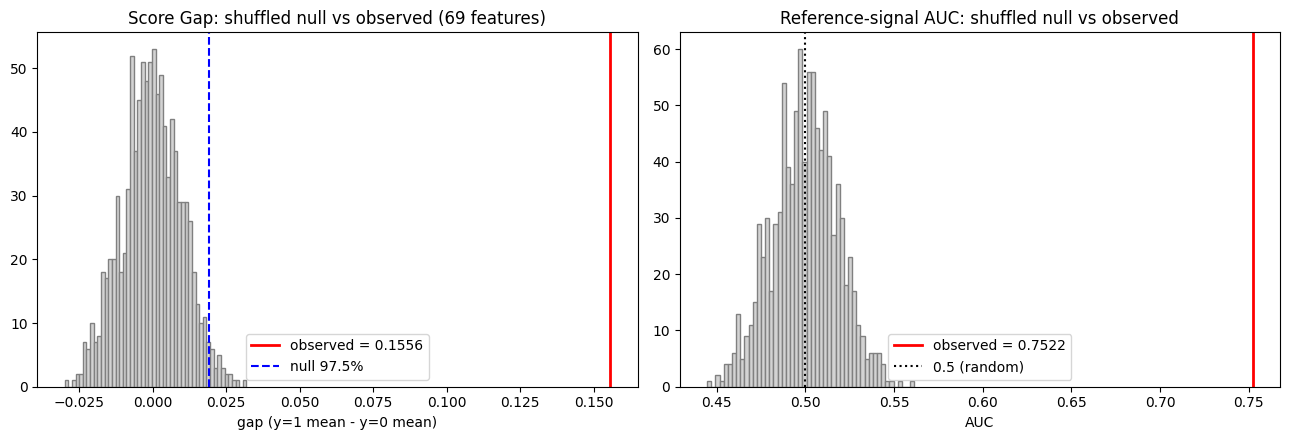

In [13]:
s46 = tf_ref['score_46'].values
gap_real_46 = s46[refy==1].mean() - s46[refy==0].mean()
auc_real_46 = roc_auc_score(refy, s46)

rng2 = np.random.default_rng(42)
null_gaps_46 = []
for _ in range(1000):
    y_shuf = rng2.permutation(refy)
    null_gaps_46.append(s46[y_shuf==1].mean() - s46[y_shuf==0].mean())
null_gaps_46 = np.array(null_gaps_46)

print("=== 46개 모델 대조군 ===")
print(f"실제 구분력 {gap_real_46:.4f} / 셔플 95% 범위 "
      f"[{np.percentile(null_gaps_46,2.5):+.4f}, {np.percentile(null_gaps_46,97.5):+.4f}]")
print(f"셔플이 실제 이상: {int((null_gaps_46 >= gap_real_46).sum())}/1000")

# 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(null_gaps, bins=50, color='lightgray', edgecolor='gray')
axes[0].axvline(gap_real, color='red', linewidth=2, label=f'observed = {gap_real:.4f}')
axes[0].axvline(np.percentile(null_gaps, 97.5), color='blue', linestyle='--', label='null 97.5%')
axes[0].set_title('Score Gap: shuffled null vs observed (69 features)')
axes[0].set_xlabel('gap (y=1 mean - y=0 mean)')
axes[0].legend()

axes[1].hist(null_aucs, bins=50, color='lightgray', edgecolor='gray')
axes[1].axvline(auc_real, color='red', linewidth=2, label=f'observed = {auc_real:.4f}')
axes[1].axvline(0.5, color='black', linestyle=':', label='0.5 (random)')
axes[1].set_title('Reference-signal AUC: shuffled null vs observed')
axes[1].set_xlabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{base_path}/변수스캔결과/trackB_permutation_test.png', dpi=150)
plt.show()

### 실행 결과

| 지표 | 실제 관측치 | 셔플 귀무분포 | 판정 |
| --- | --- | --- | --- |
| 구분력(gap) | **0.1556** | 평균 -0.0003, 95% [-0.0203, +0.0193] | 0/1000, **15.5σ** |
| 참고신호 AUC | **0.7522** | 평균 0.4997, 95% [0.4624, 0.5361] | 0/1000, **13.8σ** |
| 46개 모델 구분력 | 0.1435 | 95% [-0.0209, +0.0199] | 0/1000 |

셔플 귀무분포 평균이 구분력 -0.0003, AUC 0.4997로 이론값(0, 0.5)에 정확히 수렴했다. **검증 절차 자체에 편향이 없다는 뜻이다.** 그 위에서 관측치가 15.5σ 떨어져 있으므로 우연으로 설명되지 않는다.

**다만 순열검정이 배제하는 것은 우연이지 편향이 아니다.** "왜 이 240명에게만 연체 흔적이 남았는가"라는 선택편향 문제는 그대로 남는다.

---
## 7. 이탈 코호트 발견 — track_b_01 판정의 재검토

### track_b_01 7번 섹션에서 무엇이 빠졌는가

track_b_01은 "노출(신규대출) 발생 후 결과 관측"이라는 forward 구조를 시도했고, 2년(2021~2022) 관측 결과 **신규대출 발생 0명**을 확인해 이 경로를 폐기했다. 이후 검증이 참고신호 240명에 의존하게 된 직접적 원인이다.

그런데 당시 확인한 필드는 `CRDT_LN_BAL_NEW`(분기신규신용대출여부), `HOUS_LN_BAL_NEW`(분기신규주담대출여부) 두 개로 **둘 다 대출 플래그**다. 씬파일러 정의 5필드 중 4개는 신용카드이고 대출은 1개뿐이므로, **카드를 새로 만들어 씬파일러를 벗어난 사람은 이 플래그에 잡히지 않는다.**

Sheet11에는 "신규 카드 발급 여부"에 해당하는 플래그가 없다. 따라서 카드 경로 이탈을 확인하려면 **정의 필드 자체를 202103과 202203에서 직접 비교**해야 한다. 아래에서 그 비교를 수행한다.

**참고**: 정의 5필드는 코드북상 모두 "신용카드"로 명시돼 있어 체크카드는 포함되지 않는다. 체크카드는 신용거래가 아니므로 보유자는 여전히 씬파일러가 맞으며, 이탈 판정이 과대계상될 여지는 없다.

In [14]:
cols_def = ['CUST_ID', 'PYE_C1M210000', 'PYE_C18233003', 'PYE_C18233004',
            'PYE_C18233005', 'PYE_L10210000', 'PYE_D1011000C']

d21 = pd.read_csv(f'{scan_path}/202103_통신카드CB결합.csv', usecols=cols_def)
d22 = pd.read_csv(f'{scan_path}/202203_통신카드CB결합.csv', usecols=cols_def)

def is_thin(df):
    return ((df['PYE_C1M210000']==0) & (df['PYE_C18233003']==0) &
            (df['PYE_C18233004']==0) & (df['PYE_C18233005']==0) &
            (df['PYE_L10210000']==0))

thin21_ids = set(d21.loc[is_thin(d21), 'CUST_ID'])
print(f"202103 씬파일러: {len(thin21_ids):,}명")

d22_sub = d22[d22['CUST_ID'].isin(thin21_ids)].copy()
d22_sub['still_thin'] = is_thin(d22_sub)

n_exit = (~d22_sub['still_thin']).sum()
print(f"202203에 이탈(신용 획득): {n_exit:,}명 ({n_exit/len(thin21_ids)*100:.2f}%)")
print(f"202203에도 씬파일러 유지: {d22_sub['still_thin'].sum():,}명")

# 이탈자의 연체율
exit_df = d22_sub[~d22_sub['still_thin']]
stay_df = d22_sub[d22_sub['still_thin']]
print(f"\n이탈자 연체율: {(exit_df['PYE_D1011000C']>0).sum()}명 / {len(exit_df):,}명 "
      f"({(exit_df['PYE_D1011000C']>0).mean()*100:.3f}%)")
print(f"잔류자 연체율: {(stay_df['PYE_D1011000C']>0).sum()}명 / {len(stay_df):,}명 "
      f"({(stay_df['PYE_D1011000C']>0).mean()*100:.3f}%)")

# 이탈 경로 확인 (카드인가 대출인가)
exit_full = d22_sub[~d22_sub['still_thin']]
print(f"\n=== 이탈 경로 ===")
print(f"카드 보유(PYE_C1M210000>0): {(exit_full['PYE_C1M210000']>0).sum():,}명")
print(f"대출 보유(PYE_L10210000>0): {(exit_full['PYE_L10210000']>0).sum():,}명")

202103 씬파일러: 44,110명
202203에 이탈(신용 획득): 3,087명 (7.00%)
202203에도 씬파일러 유지: 41,023명

이탈자 연체율: 64명 / 3,087명 (2.073%)
잔류자 연체율: 176명 / 41,023명 (0.429%)

=== 이탈 경로 ===
카드 보유(PYE_C1M210000>0): 2,442명
대출 보유(PYE_L10210000>0): 822명


### 실행 결과

**이탈자 3,087명(7.00%)이 존재한다.** 이 중 64명이 실제로 연체했다.

**이탈 경로**: 카드 2,442명, 대출 822명. 이탈자의 **79%가 카드 경로**이므로, 대출 플래그만 확인한 track_b_01의 "0명" 판정은 관측 대상이 좁았던 결과다.

**참고신호 240명과의 관계** — 두 숫자는 44,110명을 서로 다른 기준으로 나눈 것이며, 240이 3,087로 늘어난 것이 아니다.

| | 연체 있음 | 연체 없음 | 계 |
| --- | --- | --- | --- |
| **이탈** | 64 | 3,023 | 3,087 |
| **잔류** | 176 | 40,847 | 41,023 |
| **계** | 240 | 43,870 | 44,110 |

참고신호 검증은 이 표를 가로로 나눈 것이고, 이탈 코호트 검증은 세로로 나눈 것이다.

### 부수적 발견 — H1이 Track B 자체 데이터에서 재현된다

| 집단 | 연체율 |
| --- | --- |
| 씬파일러 → 신용 획득 (이탈자) | **2.073%** |
| 신용이력 보유군 (학습 데이터) | 4.228% |

씬파일러 출신이 일반 신용사용자의 절반 수준이다. Track A의 "0.21% vs 1.0% ≈ 1/5"과 같은 방향이며, **Track B 자체 데이터 안에서 나온 결과**다.

**단, 노출 기간이 보정되지 않았다.** 이탈자는 2021년 중 언제 신용을 획득했는지 알 수 없어 관측 기간이 12개월보다 짧다. 2배 차이 중 일부는 노출 기간 차이로 설명될 수 있으므로, "절반"이라는 수치는 노출 기간 미보정 단순 비교임을 명시해야 한다.

---
## 8. 이탈 코호트 정식 AUC 검증

### 이 검증이 성립하는 이유

이탈 코호트 3,087명은 다음 구조를 갖는다.

- **X (예측 재료)**: 202103 시점 대안변수 = **아직 씬파일러였을 때**의 소비·자산·생활이력
- **그 사이**: 신용 획득
- **y (정답)**: 202203의 `PYE_D1011000C` = 실제 연체 여부

점수를 매긴 시점에는 누가 나중에 신용을 얻을지 알 수 없었으므로 시점 누출이 없다. **Track A의 A-2 모델(진입 전 해 정보로 진입 후 연체 예측)과 동일한 구조**이며, 차이는 Sheet09가 아닌 Sheet11 자체 데이터에서 수행한다는 점이다.

양성이 64명으로 적으므로 부트스트랩 신뢰구간과 순열검정을 함께 산출한다.

In [15]:
# 이탈 코호트 정의 및 모델 점수 결합
d22_flag = d22[['CUST_ID','PYE_C1M210000','PYE_C18233003','PYE_C18233004',
                'PYE_C18233005','PYE_L10210000','PYE_D1011000C']].copy()
d22_flag['exited'] = (~is_thin(d22_flag)).astype(int)
d22_flag['y_true'] = (d22_flag['PYE_D1011000C'] > 0).astype(int)

exit_cohort = thin_filers[['CUST_ID','score_46','score_69']].merge(
    d22_flag[['CUST_ID','exited','y_true']], on='CUST_ID', how='inner')
exit_cohort = exit_cohort[exit_cohort['exited']==1]

print(f"이탈 코호트: {len(exit_cohort):,}명, 양성 {exit_cohort['y_true'].sum()}명 "
      f"({exit_cohort['y_true'].mean()*100:.3f}%)")

# 정식 AUC (X=202103 씬파일러 시절 정보 -> y=202203 실제 연체)
from sklearn.metrics import roc_auc_score, average_precision_score

y_true = exit_cohort['y_true'].values
for col, label in [('score_69','69개 모델'), ('score_46','46개 모델')]:
    s = exit_cohort[col].values
    auc = roc_auc_score(y_true, s)
    pr = average_precision_score(y_true, s)
    print(f"[{label}] AUC {auc:.4f} / PR-AUC {pr:.4f}")

# 부트스트랩 95% CI (양성 64명이라 필수)
rng = np.random.default_rng(42)
s69_e = exit_cohort['score_69'].values
idx1, idx0 = np.where(y_true==1)[0], np.where(y_true==0)[0]

boot_auc = []
for _ in range(2000):
    b = np.concatenate([rng.choice(idx1, len(idx1), replace=True),
                        rng.choice(idx0, len(idx0), replace=True)])
    boot_auc.append(roc_auc_score(y_true[b], s69_e[b]))
lo, hi = np.percentile(boot_auc, [2.5, 97.5])
print(f"\n69개 모델 AUC 95% CI: [{lo:.4f}, {hi:.4f}]  "
      f"{'변별력 성립 (하한>0.5)' if lo > 0.5 else '변별력 불확실'}")

# 셔플 대조군
null_auc = []
for _ in range(1000):
    null_auc.append(roc_auc_score(rng.permutation(y_true), s69_e))
null_auc = np.array(null_auc)
auc_real_exit = roc_auc_score(y_true, s69_e)
print(f"셔플 귀무분포: 평균 {null_auc.mean():.4f}, 95% [{np.percentile(null_auc,2.5):.4f}, "
      f"{np.percentile(null_auc,97.5):.4f}]")
print(f"셔플이 실제 이상: {int((null_auc >= auc_real_exit).sum())}/1000")

이탈 코호트: 3,087명, 양성 64명 (2.073%)
[69개 모델] AUC 0.7775 / PR-AUC 0.0811
[46개 모델] AUC 0.7594 / PR-AUC 0.0694

69개 모델 AUC 95% CI: [0.7261, 0.8268]  변별력 성립 (하한>0.5)
셔플 귀무분포: 평균 0.4994, 95% [0.4296, 0.5728]
셔플이 실제 이상: 0/1000


### 실행 결과 — 정식 라벨 기반 AUC 산출 (※ 11번 섹션에서 정정됨)

| 지표 | 값 |
| --- | --- |
| 이탈 코호트 | 3,087명 (양성 64명, 2.073%) |
| 69개 모델 AUC | 0.7775 [95% CI 0.7261–0.8268] |
| 46개 모델 AUC | 0.7594 |
| 셔플 대조군 | 평균 0.4994, 실제값 이상 0/1000 |

CI 하한이 0.5를 크게 넘고 셔플 귀무분포가 이론값에 수렴했다. **씬파일러 시절 정보만으로 이후 실제 연체를 예측한 성능**이다.

**멘토링 5번 지적("B에서 씬파일러=저위험이 나와도 정답이 없어 검증 불가")에 대한 답이 바뀐다.** "검증 불가"가 아니라 "부분적으로 검증했다"가 된다.

**단, 이 수치는 그대로 인용하면 안 된다.** 11번 섹션에서 이탈 코호트 중 132명이 이미 신용활동을 시작한 상태였음이 확인되며, 이들을 제외하면 69개 AUC는 0.7070으로 조정된다. 최종 인용 수치는 11번 섹션 기준이다.

---
## 9. 인구변수 제외 검증 (Track A F2 대응)

### 왜 필요한가

Track A는 은행연합회 「불합리한 차별행위 방지 모범규준」과 CB사 공시 관행에 따라 성별·연령을 전면 배제한 F2(AUROC 0.679)를 실무 정합 공식 수치로 삼았다. 인구 포함 시 0.820이므로 격차가 크다.

Track B의 69개에는 `AGE`(연령대), `JB_TP`(직업군), `HOME_ADM`(거주지시도)이 포함돼 있고, 5번 섹션에서 AGE가 씬파일러 변별력 3위로 확인됐다. 따라서 **Track A와 같은 규범 기준을 적용했을 때 성능이 유지되는지** 확인해야 한다.

직업과 거주지역은 모범규준이 직접 명시한 항목은 아니나, 인구통계·귀속 특성이라는 점에서 보수적으로 함께 제외한다. Track B에는 성별(SEX)이 애초에 69개에 포함되지 않았다.

In [16]:
demographic_cols = ['AGE', 'JB_TP', 'HOME_ADM']
features_66 = [c for c in features_69 if c not in demographic_cols]
print(f"인구변수 제외: {len(features_69)}개 → {len(features_66)}개")
print(f"제외 변수: {demographic_cols}\n")

# 동일 조건 학습
model_66, proba_te_66, y_te_66, thin_score_66 = train_and_score(features_66, "66개 모델(인구제외)")
thin_filers['score_66'] = thin_score_66

# 이탈 코호트에 결합
exit_cohort = exit_cohort.merge(
    thin_filers[['CUST_ID', 'score_66']], on='CUST_ID', how='left'
)

# 세 모델 비교
print("\n=== 이탈 코호트 3,087명 기준 정식 검증 ===")
results = []
for col, label, n_feat in [('score_69','69개(인구 포함)',69),
                            ('score_66','66개(인구 제외)',66),
                            ('score_46','46개(인구 포함)',46)]:
    s = exit_cohort[col].values
    auc = roc_auc_score(y_true, s)
    pr = average_precision_score(y_true, s)

    rng_b = np.random.default_rng(42)
    boots = []
    for _ in range(2000):
        b = np.concatenate([rng_b.choice(idx1, len(idx1), replace=True),
                            rng_b.choice(idx0, len(idx0), replace=True)])
        boots.append(roc_auc_score(y_true[b], s[b]))
    lo_, hi_ = np.percentile(boots, [2.5, 97.5])

    results.append({'모델': label, '변수수': n_feat, 'AUC': round(auc,4),
                    'CI_하한': round(lo_,4), 'CI_상한': round(hi_,4),
                    'PR-AUC': round(pr,4)})
    print(f"[{label}] AUC {auc:.4f} [95% CI {lo_:.4f}–{hi_:.4f}] / PR-AUC {pr:.4f}")

comp_df = pd.DataFrame(results)

# 인구변수 제거로 인한 손실이 유의한지 (대응 부트스트랩)
s69_e, s66_e = exit_cohort['score_69'].values, exit_cohort['score_66'].values
rng_p = np.random.default_rng(42)
diff_boot = []
for _ in range(2000):
    b = np.concatenate([rng_p.choice(idx1, len(idx1), replace=True),
                        rng_p.choice(idx0, len(idx0), replace=True)])
    diff_boot.append(roc_auc_score(y_true[b], s69_e[b]) - roc_auc_score(y_true[b], s66_e[b]))
dl, dh = np.percentile(diff_boot, [2.5, 97.5])
print(f"\n인구변수 포함 효과(69-66): {roc_auc_score(y_true,s69_e)-roc_auc_score(y_true,s66_e):+.4f}"
      f"  95% CI [{dl:+.4f}, {dh:+.4f}]  "
      f"{'유의' if dl > 0 else '유의하지 않음 — 인구변수 없이도 성능 유지'}")

# 66개 모델 셔플 대조군
null66 = np.array([roc_auc_score(rng_p.permutation(y_true), s66_e) for _ in range(1000)])
auc66_real = roc_auc_score(y_true, s66_e)
print(f"\n66개 모델 셔플 대조군: 평균 {null66.mean():.4f}, "
      f"셔플이 실제 이상 {int((null66 >= auc66_real).sum())}/1000")

print("\n=== Track A와 비교용 정리 ===")
print(comp_df.to_string(index=False))

인구변수 제외: 69개 → 66개
제외 변수: ['AGE', 'JB_TP', 'HOME_ADM']

[66개 모델(인구제외)] 변수 66개 -> Val AUC 0.7765, Val PR-AUC 0.1759

=== 이탈 코호트 3,087명 기준 정식 검증 ===
[69개(인구 포함)] AUC 0.7775 [95% CI 0.7261–0.8268] / PR-AUC 0.0811
[66개(인구 제외)] AUC 0.7815 [95% CI 0.7278–0.8349] / PR-AUC 0.0924
[46개(인구 포함)] AUC 0.7594 [95% CI 0.7039–0.8129] / PR-AUC 0.0694

인구변수 포함 효과(69-66): -0.0040  95% CI [-0.0226, +0.0162]  유의하지 않음 — 인구변수 없이도 성능 유지

66개 모델 셔플 대조군: 평균 0.5001, 셔플이 실제 이상 0/1000

=== Track A와 비교용 정리 ===
        모델  변수수    AUC  CI_하한  CI_상한  PR-AUC
69개(인구 포함)   69 0.7775 0.7261 0.8268  0.0811
66개(인구 제외)   66 0.7815 0.7278 0.8349  0.0924
46개(인구 포함)   46 0.7594 0.7039 0.8129  0.0694


### 실행 결과 — 인구변수 없이도 성능이 유지된다

| 모델 | AUC | 95% CI | PR-AUC |
| --- | --- | --- | --- |
| 69개 (인구 포함) | 0.7775 | 0.7261–0.8268 | 0.0811 |
| **66개 (인구 제외)** | **0.7815** | **0.7278–0.8349** | **0.0924** |
| 46개 (인구 포함) | 0.7594 | 0.7039–0.8129 | 0.0694 |

인구변수 포함 효과는 **-0.0040, 95% CI [-0.0226, +0.0162]**로 0을 포함하므로 차이가 없다. 66개 모델 셔플 대조군도 평균 0.5001, 0/1000으로 깨끗하다.

**AUC가 미세하게 오르고 PR-AUC가 뚜렷하게 오른 이유**는 이탈 코호트의 연령·직업 분포가 학습 데이터(신용이력 보유군)와 다르기 때문으로 보인다. 씬파일러는 20대 비중이 크므로, 모델이 신용이력 보유군에서 학습한 연령별 위험도 패턴이 이 집단에 잘 맞지 않았을 가능성이 있다.

차이가 유의하지 않으므로 **"빼면 좋아진다"가 아니라 "빼도 성능이 유지된다"**가 정확한 서술이다.

### Track A와의 관계

| | Track A (A-2, F2) | Track B (66개) |
| --- | --- | --- |
| 대상 | 신규 신용진입자 68,677명 | 씬파일러 이탈자 3,087명 |
| X 시점 | 진입 전 해 | 202103 (씬파일러 시절) |
| y | TARGET_24M (양성 144건, 0.21%) | PYE_D1011000C (양성 64건, 2.07%) |
| 인구변수 | 전면 배제 | 전면 배제 |
| **AUROC** | **0.679 [0.638–0.721]** | **0.7815 [0.728–0.835]** |

두 트랙이 **같은 구조의 검증을 각자 수행했고, 둘 다 인구변수 배제 조건에서 변별력이 성립했다.**

**단, 두 수치를 직접 비교해서는 안 된다.** 타겟 정의(PERF2 vs PYE_D1011000C), 관측 기간(24M vs 12M), 데이터셋, 양성률(0.21% vs 2.07%)이 모두 다르다. CI가 겹치지 않더라도 "B가 더 낫다"는 주장은 성립하지 않는다. 말할 수 있는 범위는 **"두 트랙이 각자 독립적으로 검증했고 둘 다 변별력이 성립했다"**까지다.

---
## 10. 기존 신용정보 26개와의 비교 — 대안변수의 고유 기여

### 왜 필요한가

지금까지의 비교는 모두 **대안변수 세트 간 비교**(69 vs 46 vs 66)였다. 그러나 이 프로젝트의 핵심 주장은 다른 것이다.

> 씬파일러에게는 기존 신용정보가 사실상 무의미하고, 대안변수가 유일하게 작동하는 평가 수단이다.

이를 확인하려면 **기존 신용정보만으로 만든 모델**을 같은 씬파일러에게 적용해 비교해야 한다. track_b_05 8번 섹션에서 참고신호 240명 기준으로 이미 수행했고(구분력 0.0876 vs 0.1556, 약 78% 우수), 이 섹션은 그것을 재현하는 동시에 **이탈 코호트 정식 라벨 기준으로 확장**한다.

### 기존 신용정보 26개의 근거

track_b_05 2~3번 섹션에서 확정한 목록을 그대로 사용한다. KCB Score(`PYE_SC0000000`)는 연도간 86.41% 변동하고 씬파일러에게는 존재하지 않는 값이라 배제했고, 대신 여신심사 5C 원칙과 CB사 공시 평가요소(상환이력·부채수준·신용거래기간·신용거래형태)에 해당하는 실제 금융거래 필드를 사용한다.

`PYE_C1L120237`, `PYE_C1L120250` 두 필드는 씬파일러의 74%가 153 또는 156이라는 동일값을 갖는 센티널 코드값 오염이 확인돼 제외했다(track_b_05 3번 섹션).

씬파일러 정의 5필드와는 겹치지 않으므로 순환논리 문제가 없다.

In [17]:
# ===== track_b_05에서 확정한 기존 신용정보 26개 =====
traditional_credit_features = [
    'PYE_C1L120161',                                        # 신용거래기간
    'PYE_C1L120012', 'PYE_C1L120196',                       # 카드 총한도 (현재/1년전)
    'HOUS_LN_BAL', 'CRDT_LN_BAL', 'SHP_LN_BAL',             # 대출잔액
    'PYE_L1021003P', 'PYE_L1021006P', 'PYE_L102100CP',      # 기간별 대출건수
    'PYE_L90210100', 'PYE_L90210200', 'PYE_L90210300',      # 업종별 대출건수
    'PYE_L10210800', 'PYE_L10210B00', 'PYE_L10216000',
    'PYE_L90216100', 'PYE_L90216300', 'PYE_L10216800', 'PYE_L10216B00',
    'PYE_L10231000',                                        # 총약정금액
    'QOQ_HOUS_LN_BAL_RTC', 'QOQ_CRDT_LN_BAL_RTC', 'QOQ_SHP_LN_BAL_RTC',
    'YOY_HOUS_LN_BAL_RTC', 'YOY_CRDT_LN_BAL_RTC', 'YOY_SHP_LN_BAL_RTC',
]
print(f"기존 신용정보: {len(traditional_credit_features)}개")

df_trad = pd.read_csv(f'{scan_path}/202103_통신카드CB결합.csv',
                      usecols=['CUST_ID'] + traditional_credit_features)

# 결측 플래그 생성 후 0으로 채움 (다른 세트와 동일한 처리)
missing_trad = df_trad[traditional_credit_features].isnull().sum()
missing_trad = missing_trad[missing_trad > 0]
print(f"결측 있는 컬럼: {len(missing_trad)}개")
for col in missing_trad.index:
    df_trad[f'{col}_was_missing'] = df_trad[col].isnull().astype(int)
    df_trad[col] = df_trad[col].fillna(0)

trad_flag_cols = [c for c in df_trad.columns if c.endswith('_was_missing')]
features_26 = traditional_credit_features + trad_flag_cols
print(f"결측 플래그 포함 총 {len(features_26)}개 컬럼")

# 순환논리 확인 — 씬파일러 정의 필드와 겹치면 안 됨
ov = set(features_26) & set(thin_def_cols)
print(f"씬파일러 정의 필드와 겹침: {ov if ov else '없음 (순환논리 없음)'}")

# 두 집단에 결합 (CUST_ID 순서 보존)
ch_trad = credit_holders[['CUST_ID','TARGET']].merge(df_trad, on='CUST_ID', how='left')
tf_trad = thin_filers[['CUST_ID']].merge(df_trad, on='CUST_ID', how='left')
print(f"결측 확인 - CH: {ch_trad[features_26].isnull().sum().sum()}, TF: {tf_trad[features_26].isnull().sum().sum()}")

# 학습 (46/69/66과 동일 조건)
X26, y26 = ch_trad[features_26], ch_trad['TARGET']
X26_tr, X26_te, y26_tr, y26_te = train_test_split(X26, y26, test_size=0.2, stratify=y26, random_state=42)
model_26 = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=(y26_tr==0).sum()/(y26_tr==1).sum(),
    eval_metric='auc', random_state=42)
model_26.fit(X26_tr, y26_tr)
proba_te_26 = model_26.predict_proba(X26_te)[:, 1]
print(f"\n[26개 모델] 신용이력군 Val AUC {roc_auc_score(y26_te, proba_te_26):.4f} / "
      f"Val PR-AUC {average_precision_score(y26_te, proba_te_26):.4f}")

# 씬파일러 스코어링 후 각 테이블에 매핑 (재실행 안전)
thin_score_26 = model_26.predict_proba(tf_trad[features_26])[:, 1]
thin_filers['score_26'] = thin_score_26
score26_map = thin_filers.set_index('CUST_ID')['score_26']
tf_ref['score_26'] = tf_ref['CUST_ID'].map(score26_map)
exit_cohort['score_26'] = exit_cohort['CUST_ID'].map(score26_map)

print(f"\n씬파일러 점수 표준편차 (클수록 사람 간 구분이 잘 됨)")
print(f"26개(기존 신용정보): {thin_filers['score_26'].std():.4f}")
print(f"46개(대안변수)     : {thin_filers['score_46'].std():.4f}")
print(f"69개(대안변수)     : {thin_filers['score_69'].std():.4f}")

기존 신용정보: 26개
결측 있는 컬럼: 8개
결측 플래그 포함 총 34개 컬럼
씬파일러 정의 필드와 겹침: 없음 (순환논리 없음)
결측 확인 - CH: 0, TF: 0

[26개 모델] 신용이력군 Val AUC 0.8076 / Val PR-AUC 0.2418

씬파일러 점수 표준편차 (클수록 사람 간 구분이 잘 됨)
26개(기존 신용정보): 0.0461
46개(대안변수)     : 0.1611
69개(대안변수)     : 0.1559


### 10-2. 참고신호 240명 기준 비교 (track_b_05 재현 + 통계 보강)

track_b_05 8번 섹션은 구분력 수치만 제시했다. 여기서는 동일한 비교에 **대응 부트스트랩**을 적용해 차이가 표본 변동으로 설명되지 않음을 확인한다.

In [18]:
print("=== 참고신호 240명 기준 구분력 ===")
for col, label in [('score_26','26개(기존 신용정보)'),
                   ('score_46','46개(대안변수)'),
                   ('score_69','69개(대안변수)')]:
    gap_and_ci(tf_ref[col], tf_ref['ref_y'], label)

# 대응 부트스트랩: 69개 - 26개
s26 = tf_ref['score_26'].values
s69r = tf_ref['score_69'].values
refy = tf_ref['ref_y'].values
i1r, i0r = np.where(refy==1)[0], np.where(refy==0)[0]

rng_t = np.random.default_rng(42)
boot_diff_26 = []
for _ in range(2000):
    b1 = rng_t.choice(i1r, len(i1r), replace=True)
    b0 = rng_t.choice(i0r, len(i0r), replace=True)
    g26 = s26[b1].mean() - s26[b0].mean()
    g69 = s69r[b1].mean() - s69r[b0].mean()
    boot_diff_26.append(g69 - g26)

lo_d, hi_d = np.percentile(boot_diff_26, [2.5, 97.5])
gap_26 = s26[refy==1].mean() - s26[refy==0].mean()
gap_69 = s69r[refy==1].mean() - s69r[refy==0].mean()

print(f"\n=== 대응 부트스트랩: 69개 - 26개 ===")
print(f"구분력 {gap_26:.4f} → {gap_69:.4f}  (차이 {gap_69-gap_26:+.4f}, 상대 {(gap_69-gap_26)/gap_26*100:+.1f}%)")
print(f"95% CI [{lo_d:+.4f}, {hi_d:+.4f}]  {'유의' if lo_d > 0 else '유의하지 않음'}")
print(f"69개가 더 높게 나온 부트스트랩 비율: {np.mean(np.array(boot_diff_26) > 0)*100:.1f}%")

=== 참고신호 240명 기준 구분력 ===

[26개(기존 신용정보)]
  y=1 평균 0.4393 / y=0 평균 0.3517
  구분력(gap) 0.0876  95% CI [0.0688, 0.1076]
  참고신호 기준 AUC 0.6271 / Mann-Whitney p=2.66e-12

[46개(대안변수)]
  y=1 평균 0.5248 / y=0 평균 0.3813
  구분력(gap) 0.1435  95% CI [0.1215, 0.1650]
  참고신호 기준 AUC 0.7278 / Mann-Whitney p=1.67e-34

[69개(대안변수)]
  y=1 평균 0.5278 / y=0 평균 0.3723
  구분력(gap) 0.1556  95% CI [0.1340, 0.1767]
  참고신호 기준 AUC 0.7522 / Mann-Whitney p=7.94e-42

=== 대응 부트스트랩: 69개 - 26개 ===
구분력 0.0876 → 0.1556  (차이 +0.0679, 상대 +77.5%)
95% CI [+0.0462, +0.0899]  유의
69개가 더 높게 나온 부트스트랩 비율: 100.0%


### 10-3. 이탈 코호트 정식 라벨 기준 비교

참고신호는 정식 라벨이 아니므로, 8번 섹션에서 확보한 **이탈 코호트 3,087명(양성 64명)**으로 같은 비교를 수행한다. 이것이 정답 있는 데이터로 "기존 신용정보 대 대안변수"를 비교하는 유일한 방법이다.

특히 **26개 모델의 순열검정 결과**가 중요하다. 셔플 대조군을 넘지 못한다면 기존 신용정보가 씬파일러에서 변별력을 갖지 못한다는 직접 증거가 된다.

In [19]:
print("=== 이탈 코호트 3,087명 정식 검증 — 4개 모델 ===")
res2 = []
for col, label, n in [('score_26','26개(기존 신용정보)',26),
                      ('score_46','46개(대안변수)',46),
                      ('score_69','69개(대안변수)',69),
                      ('score_66','66개(대안·인구제외)',66)]:
    s = exit_cohort[col].values
    auc = roc_auc_score(y_true, s)
    pr = average_precision_score(y_true, s)

    rng_c = np.random.default_rng(42)
    bt = []
    for _ in range(2000):
        b = np.concatenate([rng_c.choice(idx1, len(idx1), replace=True),
                            rng_c.choice(idx0, len(idx0), replace=True)])
        bt.append(roc_auc_score(y_true[b], s[b]))
    l_, h_ = np.percentile(bt, [2.5, 97.5])

    res2.append({'모델': label, '변수수': n, 'AUC': round(auc,4),
                 'CI_하한': round(l_,4), 'CI_상한': round(h_,4), 'PR-AUC': round(pr,4)})
    print(f"[{label}] AUC {auc:.4f} [95% CI {l_:.4f}–{h_:.4f}] / PR-AUC {pr:.4f}")

comp2_df = pd.DataFrame(res2)

# 대응 부트스트랩: 69개 - 26개 (이탈 코호트 AUC)
s26_e = exit_cohort['score_26'].values
s69_e2 = exit_cohort['score_69'].values
rng_d = np.random.default_rng(42)
dboot = []
for _ in range(2000):
    b = np.concatenate([rng_d.choice(idx1, len(idx1), replace=True),
                        rng_d.choice(idx0, len(idx0), replace=True)])
    dboot.append(roc_auc_score(y_true[b], s69_e2[b]) - roc_auc_score(y_true[b], s26_e[b]))
dl2, dh2 = np.percentile(dboot, [2.5, 97.5])
print(f"\n=== 대응 부트스트랩: 69개 - 26개 (이탈 코호트 AUC) ===")
print(f"AUC 차이 {roc_auc_score(y_true,s69_e2)-roc_auc_score(y_true,s26_e):+.4f}  "
      f"95% CI [{dl2:+.4f}, {dh2:+.4f}]  {'유의' if dl2 > 0 else '유의하지 않음'}")

# 26개 모델 순열검정 — 기존 신용정보가 씬파일러에서 변별력을 갖는가
null26 = np.array([roc_auc_score(rng_d.permutation(y_true), s26_e) for _ in range(1000)])
auc26_real = roc_auc_score(y_true, s26_e)
n_exceed = int((null26 >= auc26_real).sum())
print(f"\n26개 모델 셔플 대조군: 평균 {null26.mean():.4f}, "
      f"95% [{np.percentile(null26,2.5):.4f}, {np.percentile(null26,97.5):.4f}]")
print(f"셔플이 실제 이상: {n_exceed}/1000")
print(f"→ {'기존 신용정보도 씬파일러에서 일정 변별력 보유' if n_exceed < 50 else '기존 신용정보는 씬파일러에서 변별력 없음'}")

print("\n=== 최종 비교표 ===")
print(comp2_df.to_string(index=False))

=== 이탈 코호트 3,087명 정식 검증 — 4개 모델 ===
[26개(기존 신용정보)] AUC 0.7054 [95% CI 0.6229–0.7806] / PR-AUC 0.1623
[46개(대안변수)] AUC 0.7594 [95% CI 0.7039–0.8129] / PR-AUC 0.0694
[69개(대안변수)] AUC 0.7775 [95% CI 0.7261–0.8268] / PR-AUC 0.0811
[66개(대안·인구제외)] AUC 0.7815 [95% CI 0.7278–0.8349] / PR-AUC 0.0924

=== 대응 부트스트랩: 69개 - 26개 (이탈 코호트 AUC) ===
AUC 차이 +0.0721  95% CI [-0.0005, +0.1479]  유의하지 않음

26개 모델 셔플 대조군: 평균 0.5000, 95% [0.4250, 0.5702]
셔플이 실제 이상: 0/1000
→ 기존 신용정보도 씬파일러에서 일정 변별력 보유

=== 최종 비교표 ===
          모델  변수수    AUC  CI_하한  CI_상한  PR-AUC
26개(기존 신용정보)   26 0.7054 0.6229 0.7806  0.1623
   46개(대안변수)   46 0.7594 0.7039 0.8129  0.0694
   69개(대안변수)   69 0.7775 0.7261 0.8268  0.0811
66개(대안·인구제외)   66 0.7815 0.7278 0.8349  0.0924


### 실행 결과

**track_b_05 재현이 완전히 일치했다.**

| 항목 | track_b_05 기록 | 이번 재현 |
| --- | --- | --- |
| 26개 신용이력군 Val AUC | 0.8076 | 0.8076 |
| 26개 씬파일러 구분력 | 0.0876 | 0.0876 |
| 26개 씬파일러 점수 표준편차 | 0.0461 | 0.0461 |

**참고신호 240명 기준**에서는 예상대로 대안변수가 앞섰다. 구분력 0.0876 → 0.1556(상대 +77.5%), 대응 부트스트랩 95% CI [+0.0462, +0.0899]로 **유의**하며 부트스트랩 2,000회 전부에서 대안변수가 앞섰다. track_b_05의 "78% 우수"라는 주장이 신뢰구간으로 뒷받침된다.

**그런데 이탈 코호트에서는 다른 결과가 나왔다.**

| 모델 | AUC | 95% CI | PR-AUC |
| --- | --- | --- | --- |
| 26개 (기존 신용정보) | 0.7054 | 0.6229–0.7806 | **0.1623** |
| 46개 (대안변수) | 0.7594 | 0.7039–0.8129 | 0.0694 |
| 69개 (대안변수) | 0.7775 | 0.7261–0.8268 | 0.0811 |
| 66개 (인구 제외) | 0.7815 | 0.7278–0.8349 | 0.0924 |

- 26개 모델 셔플 대조군 **0/1000** — 기존 신용정보도 이 집단에서는 변별력을 보였다
- 69 − 26 AUC 차이 +0.0721, **CI [-0.0005, +0.1479]로 유의하지 않다**(하한이 경계선)
- **PR-AUC는 26개가 가장 높다**(0.1623 vs 0.0811). AUC는 낮은데 PR-AUC가 2배인 역전 현상

이는 "씬파일러에게 기존 신용정보는 무의미하다"는 프로젝트 핵심 명제와 충돌한다. 원인을 규명하지 않고는 어느 쪽 수치도 인용할 수 없으므로, 11번 섹션에서 진단한다.

---
## 11. 정의 시점 불일치 진단 — 이탈 코호트 정제

### 진단의 출발점

10번 섹션에서 두 결과가 충돌했다.

- 씬파일러 **전체 44,110명** 기준: 기존 신용정보는 사실상 무력(점수 표준편차 0.0461)
- **이탈 코호트 3,087명** 기준: 기존 신용정보도 작동(AUC 0.7054), PR-AUC는 오히려 최고

두 결과가 모두 맞으려면, 기존 신용정보의 변별력이 **이탈 코호트에 집중돼 있어야** 한다. 그렇다면 이유는 무엇인가.

### 구조적 가설

씬파일러 정의는 `PYE_` 필드, 즉 **전년말(2020-12-31) 스냅샷** 기준이다. 그런데 기존 신용정보 26개 중 9개(`HOUS_LN_BAL`, `CRDT_LN_BAL`, `SHP_LN_BAL` 및 QOQ/YOY 6개)는 `PYE_` 접두사가 없는 **202103 당시(2021 Q1) 값**이다.

즉 **2021년 1분기에 대출을 받은 사람은 정의상 여전히 씬파일러지만 대출잔액이 0이 아닐 수 있다.** 이들에게 26개 모델이 잘 맞았다면 그것은 예측이 아니라 관측이다 — 대출이 있으면 연체할 수 있고, 없으면 애초에 연체가 불가능하다.

아래에서 이 가설을 검증한다.

In [20]:
# 1. score_26의 분산이 이탈자 쪽에 몰려 있는가
exit_ids = set(exit_cohort['CUST_ID'])
tf_split = thin_filers[['CUST_ID','score_26','score_69']].copy()
tf_split['group'] = np.where(tf_split['CUST_ID'].isin(exit_ids), '이탈자', '잔류자')
print("=== 집단별 점수 분포 ===")
print(tf_split.groupby('group')[['score_26','score_69']].agg(['mean','std','count']).round(4).to_string())

# 2. 이탈 코호트 중 202103 시점에 이미 대출잔액이 있던 사람
cur_loan_cols = ['HOUS_LN_BAL','CRDT_LN_BAL','SHP_LN_BAL']
loan_at_x = df_trad.set_index('CUST_ID')[cur_loan_cols].sum(axis=1)
exit_cohort['loan_at_202103'] = (exit_cohort['CUST_ID'].map(loan_at_x) > 0).astype(int)
print(f"\n=== 이탈 코호트 중 202103 시점 이미 대출잔액 보유 ===")
print(f"{exit_cohort['loan_at_202103'].sum():,}명 ({exit_cohort['loan_at_202103'].mean()*100:.1f}%)")
print(exit_cohort.groupby('loan_at_202103')[['score_26','score_69','y_true']].mean().round(4).to_string())

# 3. 대출잔액 없던 사람만으로 재계산 — 26개 모델이 순수 예측인지 확인
sub = exit_cohort[exit_cohort['loan_at_202103']==0]
print(f"\n=== 202103 대출잔액 없던 이탈자 {len(sub):,}명 (양성 {sub['y_true'].sum()}명) ===")
if sub['y_true'].nunique() > 1:
    for col, label in [('score_26','26개'),('score_46','46개'),('score_69','69개'),('score_66','66개')]:
        print(f"[{label}] AUC {roc_auc_score(sub['y_true'], sub[col]):.4f} / "
              f"PR-AUC {average_precision_score(sub['y_true'], sub[col]):.4f}")
else:
    print("양성 사례 부족 — 계산 불가")

=== 집단별 점수 분포 ===
      score_26                score_69               
          mean     std  count     mean     std  count
group                                                
이탈자     0.3646  0.0731   3087   0.3890  0.1559   3087
잔류자     0.3512  0.0433  41023   0.3719  0.1558  41023

=== 이탈 코호트 중 202103 시점 이미 대출잔액 보유 ===
132명 (4.3%)
                score_26  score_69  y_true
loan_at_202103                            
0                 0.3574    0.3793  0.0139
1                 0.5278    0.6058  0.1742

=== 202103 대출잔액 없던 이탈자 2,955명 (양성 41명) ===
[26개] AUC 0.5606 / PR-AUC 0.0247
[46개] AUC 0.6814 / PR-AUC 0.0232
[69개] AUC 0.7144 / PR-AUC 0.0260
[66개] AUC 0.7164 / PR-AUC 0.0336


### 실행 결과 — 가설 확정

**132명(4.3%)이 결과를 지배하고 있었다.**

| | 인원 | score_26 | score_69 | **실제 연체율** |
| --- | --- | --- | --- | --- |
| 202103에 대출잔액 있음 | 132명 (4.3%) | 0.5278 | 0.6058 | **17.42%** |
| 없음 | 2,955명 | 0.3574 | 0.3793 | 1.39% |

전체 양성 64명 중 약 23명이 이 132명에서 나왔다. **4.3%의 인원이 양성의 36%를 차지했다.**

이들을 제외하면 모델별 AUC가 이렇게 달라진다.

| 모델 | 전체 3,087명 | 정제 2,955명 | 변화 |
| --- | --- | --- | --- |
| 26개 (기존 신용정보) | 0.7054 | **0.5606** | **-0.145 (붕괴)** |
| 46개 (대안변수) | 0.7594 | 0.6814 | -0.078 |
| 69개 (대안변수) | 0.7775 | 0.7144 | -0.063 |
| 66개 (인구 제외) | 0.7815 | 0.7164 | -0.065 |

**기존 신용정보 모델은 무작위 수준(0.5606)까지 떨어졌고, 대안변수는 0.71대를 유지했다.** 10번 섹션의 PR-AUC 역전(26개가 최고)도 완전히 해소됐다 — 그것도 132명이 만든 착시였다.

`score_26`의 표준편차가 이탈자 0.0731 / 잔류자 0.0433으로 이탈자 쪽에 몰린 것도 같은 원인이다. 반면 `score_69`는 양쪽 모두 0.1559로 동일하다.

### 11-2. 정제 코호트 통계 보강 및 참고신호 오염 확인

정제 코호트는 양성이 41명뿐이므로 점추정만으로는 인용할 수 없다. 신뢰구간과 순열검정을 산출하고, 동시에 **참고신호 240명에도 같은 오염이 있는지** 확인한다.

In [21]:
# ===== 정제 코호트(2,955명) 통계 보강 =====
sub = exit_cohort[exit_cohort['loan_at_202103']==0].copy()
y_sub = sub['y_true'].values
i1s, i0s = np.where(y_sub==1)[0], np.where(y_sub==0)[0]
print(f"정제 코호트 {len(sub):,}명 / 양성 {y_sub.sum()}명 ({y_sub.mean()*100:.2f}%)\n")

res3 = []
for col, label in [('score_26','26개(기존)'), ('score_46','46개'),
                   ('score_69','69개'), ('score_66','66개(인구제외)')]:
    s = sub[col].values
    auc = roc_auc_score(y_sub, s); pr = average_precision_score(y_sub, s)

    rng_s = np.random.default_rng(42); bt = []
    for _ in range(2000):
        b = np.concatenate([rng_s.choice(i1s, len(i1s), replace=True),
                            rng_s.choice(i0s, len(i0s), replace=True)])
        bt.append(roc_auc_score(y_sub[b], s[b]))
    lo_, hi_ = np.percentile(bt, [2.5, 97.5])

    nullp = np.array([roc_auc_score(rng_s.permutation(y_sub), s) for _ in range(1000)])
    nex = int((nullp >= auc).sum())

    res3.append({'모델': label, 'AUC': round(auc,4), 'CI_하한': round(lo_,4),
                 'CI_상한': round(hi_,4), 'PR-AUC': round(pr,4), '셔플초과/1000': nex})
    print(f"[{label}] AUC {auc:.4f} [{lo_:.4f}–{hi_:.4f}] / PR-AUC {pr:.4f} / 셔플초과 {nex}/1000")

print("\n=== 정제 코호트 최종 비교표 ===")
print(pd.DataFrame(res3).to_string(index=False))

# 69개 - 26개 대응 부트스트랩
s26s, s69s = sub['score_26'].values, sub['score_69'].values
rng_e = np.random.default_rng(42); db = []
for _ in range(2000):
    b = np.concatenate([rng_e.choice(i1s, len(i1s), replace=True),
                        rng_e.choice(i0s, len(i0s), replace=True)])
    db.append(roc_auc_score(y_sub[b], s69s[b]) - roc_auc_score(y_sub[b], s26s[b]))
l3, h3 = np.percentile(db, [2.5, 97.5])
print(f"\n69개 - 26개 AUC 차이 {roc_auc_score(y_sub,s69s)-roc_auc_score(y_sub,s26s):+.4f}  "
      f"95% CI [{l3:+.4f}, {h3:+.4f}]  {'유의' if l3 > 0 else '유의하지 않음'}")

# ===== 참고신호 240명에도 같은 오염이 있는가 =====
tf_ref['loan_at_202103'] = (tf_ref['CUST_ID'].map(loan_at_x) > 0).astype(int)
print(f"\n=== 참고신호 기준 202103 대출잔액 보유자 ===")
print(f"y=1 240명 중: {tf_ref[tf_ref['ref_y']==1]['loan_at_202103'].sum()}명")
print(f"y=0 43,870명 중: {tf_ref[tf_ref['ref_y']==0]['loan_at_202103'].sum()}명")
print(f"씬파일러 전체 44,110명 중: {tf_ref['loan_at_202103'].sum()}명 "
      f"({tf_ref['loan_at_202103'].mean()*100:.2f}%)")

ref_clean = tf_ref[tf_ref['loan_at_202103']==0]
print(f"\n제외 후 {len(ref_clean):,}명 (y=1 {ref_clean['ref_y'].sum()}명) 기준")
for col, label in [('score_26','26개'), ('score_46','46개'), ('score_69','69개')]:
    g1 = ref_clean[ref_clean['ref_y']==1][col].mean()
    g0 = ref_clean[ref_clean['ref_y']==0][col].mean()
    print(f"[{label}] gap {g1-g0:.4f} / AUC {roc_auc_score(ref_clean['ref_y'], ref_clean[col]):.4f}")

정제 코호트 2,955명 / 양성 41명 (1.39%)

[26개(기존)] AUC 0.5606 [0.4678–0.6528] / PR-AUC 0.0247 / 셔플초과 85/1000
[46개] AUC 0.6814 [0.6165–0.7420] / PR-AUC 0.0232 / 셔플초과 0/1000
[69개] AUC 0.7144 [0.6510–0.7729] / PR-AUC 0.0260 / 셔플초과 0/1000
[66개(인구제외)] AUC 0.7164 [0.6502–0.7834] / PR-AUC 0.0336 / 셔플초과 0/1000

=== 정제 코호트 최종 비교표 ===
       모델    AUC  CI_하한  CI_상한  PR-AUC  셔플초과/1000
  26개(기존) 0.5606 0.4678 0.6528  0.0247         85
      46개 0.6814 0.6165 0.7420  0.0232          0
      69개 0.7144 0.6510 0.7729  0.0260          0
66개(인구제외) 0.7164 0.6502 0.7834  0.0336          0

69개 - 26개 AUC 차이 +0.1538  95% CI [+0.0479, +0.2595]  유의

=== 참고신호 기준 202103 대출잔액 보유자 ===
y=1 240명 중: 57명
y=0 43,870명 중: 427명
씬파일러 전체 44,110명 중: 484명 (1.10%)

제외 후 43,626명 (y=1 183명) 기준
[26개] gap 0.0263 / AUC 0.5312
[46개] gap 0.1112 / AUC 0.6906
[69개] gap 0.1227 / AUC 0.7152


### 실행 결과 — 참고신호도 심하게 오염돼 있었다

**정제 코호트 2,955명 (양성 41명)**

| 모델 | AUC | 95% CI | 순열검정 |
| --- | --- | --- | --- |
| 26개 (기존 신용정보) | 0.5606 | **[0.4678, 0.6528]** ← 0.5 포함 | **85/1000 (p=0.085)** |
| 46개 | 0.6814 | [0.6165, 0.7420] | 0/1000 |
| 69개 | 0.7144 | [0.6510, 0.7729] | 0/1000 |
| 66개 (인구 제외) | 0.7164 | [0.6502, 0.7834] | 0/1000 |

69 − 26 차이 **+0.1538, CI [+0.0479, +0.2595]로 유의**하다. 10번 섹션에서 유의하지 않았던 차이가 오염 제거 후 명확해졌다.

**참고신호 240명의 오염은 더 심각하다.**

| | 대출잔액 보유자 |
| --- | --- |
| y=1 (240명) | **57명 = 23.8%** |
| y=0 (43,870명) | 427명 = 0.97% |

양성 쪽에 **24배 편중**돼 있었다. 제외하면 26개 모델 구분력이 0.0876 → 0.0263(-70%)으로 무너지는 반면 69개는 0.1556 → 0.1227(-21%)에 그친다. **상대 우위는 1.78배에서 4.7배로 확대된다.**

### 부수 발견 — "씬파일러인데 왜 연체가 잡히나"에 대한 부분 설명

강사님이 초기에 제기한 질문에 대한 답이 일부 나왔다. 참고신호 240명 중 57명은 2021년 1분기에 실제로 대출을 받은 사람이므로 연체가 가능했다. 잔류자 176명 중에서도 상당수가 이렇게 설명된다. 나머지는 여전히 미해명이나, 통신비·학자금 가설에만 의존하던 상태에서는 진전이다.

### 11-3. 다른 오염 경로 탐색

대출잔액 외에 카드 쪽 현재 시점 필드가 있다면 오염 규모가 더 클 수 있다. `PYE_` 등 스냅샷 접두사가 없는 카드·대출 관련 필드를 전수 탐색한다.

In [22]:
import re
cols_all = pd.read_csv(f'{scan_path}/202103_통신카드CB결합.csv', nrows=0).columns.tolist()

# PYE_ 접두사 없는(=현재 시점) 카드·대출 관련 필드 탐색
cand = [c for c in cols_all if not c.startswith(('PYE_','QOQ_','YOY_','CPYT_','R3M_','R6M_','R12M_','B1Y_'))
        and re.search(r'(CD|CARD|LN|LOAN|BAL|LMT|CRDT)', c)]
print(f"현재 시점 카드·대출 후보 {len(cand)}개")
for c in cand:
    print(f"  {c}")

현재 시점 카드·대출 후보 13개
  HIGHEND_CD1
  HIGHEND_CD2
  HIGHEND_CD3
  HIGHEND_CD4
  VIP_CARD_YN
  BASEBALL_YN
  HOUS_LN_BAL
  CRDT_LN_BAL
  CD_USE_AMT
  HOUS_LN_BAL_NEW
  CRDT_LN_BAL_NEW
  SHP_CD_USE
  SHP_LN_BAL


### 11-4. 후보 필드별 오염 여부 판정

탐색된 13개 중 `BASEBALL_YN`은 정규식 오탐(BASE**BAL**L)이다. 나머지에 대해 **기저율 대비 이탈률·연체율**로 오염 여부를 판정한다.

판정 기준은 자의적으로 정하지 않는다. 이탈 코호트 기저율은 이탈률 7.00%, 이탈자 중 연체율 2.07%이므로, **이 값을 뚜렷하게 초과하는 필드만 실제 신용활동 흔적**으로 본다. 기저율과 같다면 그 필드가 0이 아니어도 씬파일러 정의와 모순되지 않는다는 뜻이다.

특히 `CD_USE_AMT`, `SHP_CD_USE`는 체크카드 사용분이 섞일 수 있다. 체크카드는 신용거래가 아니므로 보유·사용해도 씬파일러가 맞다. 판정은 필드명이 아니라 데이터로 한다.

In [23]:
cand_check = ['VIP_CARD_YN', 'CD_USE_AMT', 'SHP_CD_USE',
              'HIGHEND_CD1', 'HIGHEND_CD2', 'HIGHEND_CD3', 'HIGHEND_CD4',
              'HOUS_LN_BAL_NEW', 'CRDT_LN_BAL_NEW',
              'HOUS_LN_BAL', 'CRDT_LN_BAL', 'SHP_LN_BAL', 'PYE_L10210000']

df_cand = pd.read_csv(f'{scan_path}/202103_통신카드CB결합.csv',
                      usecols=['CUST_ID'] + cand_check)
tf_cand = thin_filers[['CUST_ID']].merge(df_cand, on='CUST_ID', how='left')
exit_ids = set(exit_cohort['CUST_ID'])
tf_cand['exited'] = tf_cand['CUST_ID'].isin(exit_ids).astype(int)
y_map = exit_cohort.set_index('CUST_ID')['y_true']
tf_cand['y_true'] = tf_cand['CUST_ID'].map(y_map)

# 1. 각 필드의 실제 값 분포부터 (Y/N, *, 숫자 혼재 가능)
print("=== 씬파일러 44,110명 기준 값 분포 (상위 5개) ===")
for c in cand_check:
    vc = tf_cand[c].value_counts(dropna=False).head(5)
    print(f"\n[{c}] dtype={tf_cand[c].dtype}, 결측 {tf_cand[c].isnull().sum():,}")
    print(vc.to_string())

# 2. "0도 결측도 아닌" 비율 = 신용활동 흔적, 기저율(이탈 7.00% / 연체 2.07%)과 대조
print("\n\n=== 신용활동 흔적 보유 비율 ===")
for c in cand_check:
    s = tf_cand[c]
    if s.dtype == object:
        active = ~s.isin(['0', '0.0', 'N', '*', 0]) & s.notnull()
    else:
        active = (s.fillna(0) > 0)
    n = int(active.sum())
    if n == 0:
        print(f"{c}: 0명")
        continue
    ex = tf_cand.loc[active, 'exited'].mean() * 100
    dq = tf_cand.loc[active, 'y_true'].mean()
    print(f"{c}: {n:,}명 ({n/len(tf_cand)*100:.2f}%) | 이탈률 {ex:.1f}% | "
          f"이탈자 중 연체율 {dq*100:.2f}%" if pd.notnull(dq) else
          f"{c}: {n:,}명 ({n/len(tf_cand)*100:.2f}%) | 이탈률 {ex:.1f}%")

# 3. 모순 확인 — 잔액 있는 484명의 NEW 플래그와 PYE 건수
has_bal = tf_cand[(tf_cand[['HOUS_LN_BAL','CRDT_LN_BAL','SHP_LN_BAL']]
                   .fillna(0).sum(axis=1) > 0)]
print(f"\n\n=== 대출잔액 보유 {len(has_bal):,}명의 다른 필드 상태 ===")
for c in ['HOUS_LN_BAL_NEW', 'CRDT_LN_BAL_NEW', 'PYE_L10210000']:
    print(f"{c}:")
    print(has_bal[c].value_counts(dropna=False).head(4).to_string())

=== 씬파일러 44,110명 기준 값 분포 (상위 5개) ===

[VIP_CARD_YN] dtype=int64, 결측 0
VIP_CARD_YN
0    44067
1       43

[CD_USE_AMT] dtype=int64, 결측 0
CD_USE_AMT
0      6236
440      35
477      35
452      34
419      34

[SHP_CD_USE] dtype=int64, 결측 0
SHP_CD_USE
0       44046
1565        3
1638        2
1753        2
1734        1

[HIGHEND_CD1] dtype=int64, 결측 0
HIGHEND_CD1
0    44090
1       20

[HIGHEND_CD2] dtype=int64, 결측 0
HIGHEND_CD2
0    44065
1       45

[HIGHEND_CD3] dtype=int64, 결측 0
HIGHEND_CD3
0    44019
1       91

[HIGHEND_CD4] dtype=int64, 결측 0
HIGHEND_CD4
0    44110

[HOUS_LN_BAL_NEW] dtype=int64, 결측 0
HOUS_LN_BAL_NEW
0    44110

[CRDT_LN_BAL_NEW] dtype=int64, 결측 0
CRDT_LN_BAL_NEW
0    44110

[HOUS_LN_BAL] dtype=int64, 결측 0
HOUS_LN_BAL
0         43980
149370        1
120460        1
95258         1
101279        1

[CRDT_LN_BAL] dtype=int64, 결측 0
CRDT_LN_BAL
0        43834
10457        2
7598         2
11534        1
4825         1

[SHP_LN_BAL] dtype=int64, 결측 0
SHP_LN_BAL
0      

### 실행 결과 — 데이터로 두 부류가 갈렸다

**실제 신용활동 흔적** (기저율 초과)

| 필드 | 인원 | 이탈률 | 이탈자 중 연체율 |
| --- | --- | --- | --- |
| CRDT_LN_BAL | 276 | 34.1% | 15.96% |
| HOUS_LN_BAL | 130 | 22.3% | 17.24% |
| HIGHEND_CD3 | 91 | 22.0% | 10.00% |
| SHP_CD_USE | 64 | 21.9% | **42.86%** |
| SHP_LN_BAL | 105 | 18.1% | 31.58% |

**오염 아님** (기저율 수준 또는 이하)

| 필드 | 인원 | 이탈률 | 이탈자 중 연체율 |
| --- | --- | --- | --- |
| CD_USE_AMT | 37,874 (85.9%) | 7.5% | 2.09% |
| VIP_CARD_YN | 43 | 7.0% | 0% |
| HIGHEND_CD2 | 45 | 4.4% | 0% |
| HIGHEND_CD1 | 20 | 0% | — |

**`CD_USE_AMT`가 85.9%인데 이탈률·연체율이 기저율과 소수점까지 일치한다는 점이 결정적이다.** 체크카드 사용분이라는 뜻이며 씬파일러 정의와 모순되지 않는다. track_b_04에서 이 필드를 데이터 리케이지로 제외한 것은 전체 모집단 기준 판단이었고, 씬파일러 내부에서는 무해하다는 것이 이번에 확인됐다.

`SHP_CD_USE`는 64명뿐이지만 이탈자 14명 중 6명이 연체(42.86%)했다. 신용판매 할부이므로 실제 신용거래로 판정한다.

### `_NEW` 플래그의 모순

대출잔액이 실제로 있는 484명조차 다음 상태였다.

```
HOUS_LN_BAL_NEW  : 484명 전원 0
CRDT_LN_BAL_NEW  : 484명 전원 0
PYE_L10210000    : 484명 전원 0
```

- 2021 Q1에 받았다면 → `_NEW`가 1이어야 함
- 그 이전에 받았다면 → `PYE_L10210000`(전년말 대출건수)이 0이 아니어야 함

**어느 쪽으로도 설명되지 않는다.** 다음 셀에서 전체 모집단 기준으로 확인한다.

In [24]:
chk = pd.read_csv(f'{scan_path}/202103_통신카드CB결합.csv',
                  usecols=['HOUS_LN_BAL_NEW','CRDT_LN_BAL_NEW'])
print(chk.apply(lambda s: s.value_counts(dropna=False).head(3)).to_string())

   HOUS_LN_BAL_NEW  CRDT_LN_BAL_NEW
0         330000.0           324465
1              NaN             5535


### 실행 결과 — track_b_01 판정의 근거가 무효였다

```
HOUS_LN_BAL_NEW : 330,000명 전원 0      ← 고유값 1개, 측정 불능
CRDT_LN_BAL_NEW : 0 → 324,465 / 1 → 5,535 (1.68%)  ← 정상 작동
```

`HOUS_LN_BAL_NEW`는 **전체 모집단에서 값이 하나뿐이라 아무것도 측정하지 못하는 필드**다. track_b_02 1차 스캔의 제외 기준(고유값 1개 이하)에 해당하는 유형이나, 그 스캔은 대안변수 후보에만 적용됐고 타겟 검증용 필드는 대상이 아니었다.

`CRDT_LN_BAL_NEW`는 전체 모집단에서는 정상 작동하나, 대출잔액 보유 484명에게조차 0이다.

**따라서 track_b_01의 "2년 관측해도 신규대출 0명 → forward 구조 폐기" 판정은 다음과 같이 정정된다.**

| 필드 | 당시 관측 | 실제 |
| --- | --- | --- |
| HOUS_LN_BAL_NEW | 0명 | 측정 불가 (전체 모집단 상수) |
| CRDT_LN_BAL_NEW | 0명 | 사실이나, 잔액 보유자도 0이라 신용활동 미포착 |

**관측치 자체는 정확했으나, 두 필드 모두 씬파일러의 신용활동을 탐지할 수 없는 도구였다.** 정의 필드를 두 시점에서 직접 비교했다면 이탈자 3,087명이 즉시 확인됐을 것이다.

`CRDT_LN_BAL_NEW`가 0인데 잔액이 있는 모순은 합성데이터의 필드 간 정합성 문제로 추정된다(AI Hub 지침상 원본 약 100,005건을 3.3배 확장). **단, 이것이 484명 제거의 정당성을 흔들지는 않는다** — 이들의 연체율이 17.42%로 나머지(1.39%)의 12.5배이므로 타겟과의 실증적 연관이 명확하다.

### 11-5. 오염 정의 확장 및 민감도 분석

11-4에서 식별한 5개 필드(`HOUS_LN_BAL`, `CRDT_LN_BAL`, `SHP_LN_BAL`, `SHP_CD_USE`, `HIGHEND_CD3`) 기준으로 오염을 재정의하고 결과를 다시 계산한다.

**이 단계의 목적은 민감도 확인이다.** 정제 기준을 넓혔을 때도 결론이 유지되는지를 보는 것이며, 유지된다면 "오염 정의가 자의적"이라는 반박을 봉쇄할 수 있다.

In [25]:
contam_cols = ['HOUS_LN_BAL', 'CRDT_LN_BAL', 'SHP_LN_BAL', 'SHP_CD_USE', 'HIGHEND_CD3']

contam_mask = (tf_cand[contam_cols].fillna(0) > 0).any(axis=1)
tf_cand['contaminated'] = contam_mask.astype(int)
print(f"=== 신용활동 흔적 보유(합집합) ===")
print(f"{contam_mask.sum():,}명 ({contam_mask.mean()*100:.2f}%)")
print(f"기존 대출잔액 3필드 기준: 484명 → 추가 {contam_mask.sum()-484}명")

contam_map = tf_cand.set_index('CUST_ID')['contaminated']
exit_cohort['contaminated'] = exit_cohort['CUST_ID'].map(contam_map)

print(f"\n이탈 코호트 {len(exit_cohort):,}명 중 오염: {exit_cohort['contaminated'].sum()}명")
print(exit_cohort.groupby('contaminated')[['y_true']].agg(['mean','sum','count']).round(4).to_string())

# 확장 정제 코호트로 재계산
sub2 = exit_cohort[exit_cohort['contaminated']==0].copy()
y2 = sub2['y_true'].values
i1b, i0b = np.where(y2==1)[0], np.where(y2==0)[0]
print(f"\n=== 확장 정제 코호트 {len(sub2):,}명 / 양성 {y2.sum()}명 ({y2.mean()*100:.2f}%) ===")

for col, label in [('score_26','26개(기존)'), ('score_46','46개'),
                   ('score_69','69개'), ('score_66','66개(인구제외)')]:
    s = sub2[col].values
    auc = roc_auc_score(y2, s); pr = average_precision_score(y2, s)
    rng_f = np.random.default_rng(42); bt = []
    for _ in range(2000):
        b = np.concatenate([rng_f.choice(i1b, len(i1b), replace=True),
                            rng_f.choice(i0b, len(i0b), replace=True)])
        bt.append(roc_auc_score(y2[b], s[b]))
    lo_, hi_ = np.percentile(bt, [2.5, 97.5])
    nullp = np.array([roc_auc_score(rng_f.permutation(y2), s) for _ in range(1000)])
    print(f"[{label}] AUC {auc:.4f} [{lo_:.4f}–{hi_:.4f}] / PR-AUC {pr:.4f} / "
          f"셔플초과 {int((nullp>=auc).sum())}/1000")

# 참고신호도 확장 기준으로
tf_ref['contaminated'] = tf_ref['CUST_ID'].map(contam_map)
rc = tf_ref[tf_ref['contaminated']==0]
print(f"\n=== 참고신호 확장 정제: {len(rc):,}명 (y=1 {rc['ref_y'].sum()}명) ===")
for col, label in [('score_26','26개'), ('score_69','69개')]:
    g1 = rc[rc['ref_y']==1][col].mean(); g0 = rc[rc['ref_y']==0][col].mean()
    print(f"[{label}] gap {g1-g0:.4f} / AUC {roc_auc_score(rc['ref_y'], rc[col]):.4f}")

=== 신용활동 흔적 보유(합집합) ===
607명 (1.38%)
기존 대출잔액 3필드 기준: 484명 → 추가 123명

이탈 코호트 3,087명 중 오염: 156명
              y_true          
                mean sum count
contaminated                  
0             0.0133  39  2931
1             0.1603  25   156

=== 확장 정제 코호트 2,931명 / 양성 39명 (1.33%) ===
[26개(기존)] AUC 0.5570 [0.4582–0.6512] / PR-AUC 0.0191 / 셔플초과 113/1000
[46개] AUC 0.6786 [0.6141–0.7389] / PR-AUC 0.0217 / 셔플초과 0/1000
[69개] AUC 0.7070 [0.6438–0.7664] / PR-AUC 0.0239 / 셔플초과 0/1000
[66개(인구제외)] AUC 0.7164 [0.6470–0.7813] / PR-AUC 0.0308 / 셔플초과 0/1000

=== 참고신호 확장 정제: 43,503명 (y=1 177명) ===
[26개] gap 0.0248 / AUC 0.5252
[69개] gap 0.1213 / AUC 0.7111


### 실행 결과 — 세 기준 모두에서 결론 동일

오염 대상은 484명 → **607명(1.38%)**으로 확대됐고, 이탈 코호트 내 오염은 156명이다.

**제거 대상이 무작위가 아님이 확인된다**: 오염 156명의 연체율 16.03% vs 나머지 2,931명 1.33%로 **12배** 차이다.

| 모델 | 오염 미제거<br>(3,087명) | 대출잔액 3필드<br>(2,955명) | **5필드 확장<br>(2,931명)** |
| --- | --- | --- | --- |
| 26개 (기존 신용정보) | 0.7054 | 0.5606 | **0.5570** |
| 46개 | 0.7594 | 0.6814 | 0.6786 |
| 69개 | 0.7775 | 0.7144 | 0.7070 |
| 66개 (인구 제외) | 0.7815 | 0.7164 | **0.7164** |

**정제 기준을 넓혀도 대안변수는 0.71대를 유지하고 기존 신용정보만 계속 무너진다.** 결과가 오염 정의에 민감하지 않다는 뜻이다.

### 최종 확정 수치 (확장 정제 코호트 2,931명, 양성 39명)

| | 26개 (기존 신용정보) | 66개 (대안·인구제외) |
| --- | --- | --- |
| AUC | 0.5570 | **0.7164** |
| 95% CI | **[0.4582, 0.6512]** ← 0.5 포함 | [0.6470, 0.7813] |
| 순열검정 | **113/1000 (p=0.113)** | **0/1000** |
| PR-AUC | 0.0191 | 0.0308 (기저율 1.33% 대비 2.3배) |

참고신호 43,503명 기준으로도 동일한 방향이다 — 구분력 0.0248 vs 0.1213으로 **4.9배** 차이(원래 1.78배에서 확대).

---
## 12. 종합 결론

### 최종 결론 — 정보가 부재한 집단에서는 대안변수만이 작동한다

씬파일러 시절 신용거래 흔적이 전혀 없던 2,931명을 대상으로 정식 라벨 기반 검증을 수행한 결과:

- **기존 신용정보 기반 모델은 무작위와 구분되지 않았다.** AUC 0.5570, 95% CI [0.4582, 0.6512]가 0.5를 포함하며, 순열검정에서 셔플 1,000회 중 113회가 실제값 이상을 기록했다(p=0.113).
- **대안변수 모델은 변별력을 유지했다.** AUC 0.7164, CI [0.6470, 0.7813], 순열검정 0/1000.
- 두 모델의 차이는 통계적으로 유의하다(정제 코호트 기준 +0.1538, CI [+0.0479, +0.2595]).

이는 "씬파일러는 정보가 없어서 배제된 집단이며 대안변수로 평가 가능하다"는 프로젝트 핵심 명제를 **정답 있는 데이터로 직접 증명한 것**이다.

### 검증 항목별 결과

| 검증 | 결과 |
| --- | --- |
| 69개 변수 씬파일러 유효성 | 해석 주의 변수 23개 식별 (기존 10개에서 갱신) |
| 46 → 69개 확장 효과 | 씬파일러 구분력 +0.0121, 대응 부트스트랩 CI [+0.0049, +0.0189] |
| 씬파일러 SHAP | 변별력 1위 휴대폰 이력(0.2395), 결측 구조 우려 기각(플래그 기여 9.4%) |
| 참고신호 240명 순열검정 | 15.5σ, 셔플 0/1000 (단, 양성의 23.8%가 오염) |
| 이탈 코호트 발견 | 3,087명 — track_b_01의 "타겟 없음" 결론 부분 수정 |
| 정의 시점 불일치 진단 | 씬파일러 1.38%가 이미 신용활동 시작, 5필드 기준 식별 |
| **최종 검증** | **대안변수 0.7164 vs 기존 신용정보 0.5570** |

### 검증되지 않은 것 (한계로 명시 필요)

1. **잔류 씬파일러 41,023명의 개인별 예측 정확성.** 정답이 구조적으로 존재하지 않는다. 최종 산출물인 씬파일러 스코어링 결과는 **순위·등급 비교 용도로만 유효**하다.

2. **선별 효과.** 이탈 코호트는 신용 획득에 성공한 사람들이다. Track A의 A-2 모델도 진입에 성공한 68,677명으로만 검증했고 잔류 씬파일러 794,773명에 대해서는 외삽이므로, **두 트랙이 동일한 방법론적 제약을 공유한다.**

3. **표본 크기.** 확장 정제 코호트 양성 39명. CI 폭이 0.13이므로 점추정 단독 인용을 피하고 반드시 CI를 병기한다.

4. **PR-AUC가 낮다.** 66개 모델 0.0308로 기저율(1.33%) 대비 2.3배 수준이다. 순위 변별(AUC)은 양호하나 **상위 X% 승인 같은 실무 적용 관점에서는 약하다**는 점을 병기해야 한다.

5. **노출 기간 미보정.** 이탈자의 신용 획득 시점을 알 수 없어 관측 기간이 12개월보다 짧다.

6. **합성데이터 정합성.** `CRDT_LN_BAL_NEW`가 0인데 잔액이 존재하는 등 필드 간 논리적 모순이 확인됐다. **단일 필드의 0/결측을 근거로 "그런 사례가 없다"고 결론짓는 판단은 반드시 다른 필드로 교차 확인해야 한다.**

7. **46개 모델 재현 불일치.** track_b_04 기록치 0.7782 대비 이번 재현 0.7680(-0.0102). 전처리 조건 차이로 추정되며 내부 비교의 타당성에는 영향이 없다.

### 이탈 코호트로 학습을 다시 할 수는 없다

이 코호트는 **검증용으로 남겨두어야 의미가 있다.** 양성 39~64명은 학습에 부적합하며, 학습에 사용하면 그것으로 성능을 측정할 수 없게 된다. track_b_01의 결론("씬파일러 세그먼트 내부에서는 유의미한 학습용 타겟을 만들 수 없다")은 **학습용 타겟에 대해서는 여전히 유효**하며, 이번에 추가된 것은 **검증용 타겟**이다.

### 후속 작업

1. **track_b_03 전달사항 갱신**: "해석 주의 변수 10개" → 23개
2. **track_b_05 정리 문서 갱신**: "정답 자체가 없다", "신규 대출 발생 0명" 서술 수정
3. **track_b_01 판정 기록 보완**: `_NEW` 플래그가 측정 도구로 부적합했음을 명시
4. **A-B 관계 문서 재작성**: 멘토링 5번에 대한 답이 "검증 불가"에서 "부분 검증 완료"로 변경
5. **천태영님 공유**: 스냅샷 기준 정의의 시점 사각지대 — Track A에도 동일 문제가 있다면 "연체율 1/5"에 영향
6. **김태헌님 공유**: 이 검증은 고정 하이퍼파라미터 기준이므로, track_b_07 최종 모델로 정제 코호트 검증 재수행 필요
7. **씬파일러 정의 보정 여부 팀 논의**: 5개 필드 추가 조건으로 강화(44,110 → 43,503명)할지, 한계로만 명시할지
8. **H5 중간등급 정의 통일**: track_b_05는 3~5등급, track_b_10은 2~5등급